<a href="https://colab.research.google.com/github/jovitaand/The-Effects-of-Stress-in-Gene-Expression-in-Adipose-Tissues/blob/main/Similarity_Check.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Metabolomics analysis — scW / BAT metabolite profiling

Untargeted LC-MS analysis of subcutaneous white (scW) and brown (BAT) adipose
tissue from control, CMVS and CSDS animals, following the full data-science
lifecycle:

> Raw data → QC → cleaning → missing values → normalisation & scaling →
> exploratory analysis → machine learning → validation → biomarker discovery →
> biological interpretation

The target is to **reproduce a SIMCA (Sartorius/Umetrics) model summary table
exactly**, then subject those models to validation the summary table does not
report.

---

## Recovered preprocessing settings

The reference table does not state its preprocessing. These settings were
**recovered** by scanning normalisation × transformation × scaling against the
published R²X values — not assumed. Exactly one combination reproduces them:

| setting | value | evidence |
|---|---|---|
| normalisation | none (raw peak areas) | — |
| transformation | **none** (no log) | log2+Pareto gives R²X(2)=0.496, not 0.609 |
| scaling | **Pareto** | raw+UV gives 0.402, not 0.609 |
| cross-validation | **7 groups, `i mod 7`** | SIMCA default; block CV gives 0.282 vs 0.192 |
| Q² | **Wold cumulative product** | see §3.3 |
| outlier | **BAT_Aq_CMVS6 (F27)** | only sample explaining every count: 52→51, 22→21, 18→17, 12→11, 12→12 |

## Reproduction status

- **R²X: 11/11 exact**
- **R²Y: 6/6 exact**
- **Q²: 8/11** within 0.006

Three Q² values are *not* reproduced and are reported honestly rather than
tuned to match — see the closing section for why.

**Independent confirmation:** the workbook carries its own SIMCA-computed VIP
columns, which were not used to tune anything. This notebook reproduces all
four at Spearman ρ = 1.0000. That is a stricter test of the whole
preprocessing + PLS chain than the summary table itself.

---

**Runtime** ≈ 25 min at `N_PERM=1000`; the permutation test dominates. Set
`N_PERM=100` in the config cell for a fast pass.

## 1. Environment and configuration

Every knob that affects a result is in one place. Nothing below this cell
hard-codes a preprocessing choice.

In [1]:
import os
import sys
import textwrap
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# =============================================================================
# CONFIGURATION
# =============================================================================
XLSX = os.environ.get(
    "METAB_XLSX",
    "/content/Yana copy_24April26_scW_BAT_metabolite_profiling_Data_ID.xlsx",
)
OUTDIR = os.environ.get("METAB_OUT", "/mnt/user-data/outputs/metabolomics")
FIGDIR = os.path.join(OUTDIR, "figures")
TABDIR = os.path.join(OUTDIR, "tables")
for d in (OUTDIR, FIGDIR, TABDIR):
    os.makedirs(d, exist_ok=True)

# Preprocessing settings.  These were not guessed -- they are the settings that
# reproduce the reference SIMCA table exactly (see PHASE 4/5 notes and the
# validation table at the end).
NORMALISATION = "none"      # peak areas used as reported by Compound Discoverer
TRANSFORM = "none"          # no log transform in the reference models
SCALING = "pareto"          # SIMCA "Par"
CV_GROUPS = 7               # SIMCA default number of cross-validation groups
CV_SCHEME = "every_nth"     # SIMCA default: group(i) = i mod 7
N_PERM = int(os.environ.get("N_PERM", 1000))

# Sample flagged as a strong outlier in the reference analysis and excluded
# from the "no outlier" models. Its identity is recoverable from the sample
# counts in the reference table (52->51, BAT 22->21, BAT PLS-DA 18->17,
# BAT control-vs-CMVS 12->11, BAT control-vs-CSDS unchanged at 12).
OUTLIER = "Area: BAT_Aq_CMVS6.raw (F27)"

PALETTE = {"control": "#4C72B0", "CMVS": "#DD8452", "CSDS": "#55A868",
           "QC": "#8172B3", "Blank": "#937860"}

_LOG = []


def log(msg=""):
    print(msg)
    _LOG.append(str(msg))


def head(title):
    log("\n" + "=" * 78)
    log(title)
    log("=" * 78)

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200

print(f"Python      {sys.version.split()[0]}")
print(f"numpy       {np.__version__}")
print(f"pandas      {pd.__version__}")
print(f"matplotlib  {matplotlib.__version__}")
print(f"scikit-learn {__import__('sklearn').__version__}")
print()
print(f"Workbook    {XLSX}")
print(f"Output dir  {OUTDIR}")
print(f"Scaling     {SCALING} | transform {TRANSFORM} | CV {CV_GROUPS} groups ({CV_SCHEME})")
print(f"Permutations {N_PERM}  |  seed {RANDOM_SEED}")


Python      3.13.15
numpy       2.1.3
pandas      2.2.3
matplotlib  3.10.0
scikit-learn 1.6.1

Workbook    /content/Yana copy_24April26_scW_BAT_metabolite_profiling_Data_ID.xlsx
Output dir  /mnt/user-data/outputs/metabolomics
Scaling     pareto | transform none | CV 7 groups (every_nth)
Permutations 1000  |  seed 42


## 2. Chemometrics engine

SIMCA does not use scikit-learn's PLS, and the difference is not cosmetic.
Two details decide whether the numbers match a SIMCA report:

1. **Q² is cumulative over components**, via the Wold formula

   $$Q^2(\text{cum}) = 1 - \prod_a \frac{\mathrm{PRESS}_a}{\mathrm{SS}_{a-1}}$$

   where $\mathrm{PRESS}_a$ comes from cross-validating **one** component on
   the residual matrices left by the previous *full-data* components. It is
   **not** $1 - \mathrm{PRESS}/\mathrm{SS}$ of a refitted $A$-component model.
   Using the wrong one gives wildly different (usually strongly negative)
   values on these sample sizes.

2. **The default CV partition is 7 groups by observation order**,
   $\text{group}(i) = i \bmod 7$ — not contiguous blocks, not leave-one-out.
   With $n \approx 12$ this materially changes Q².

Both were verified empirically against the reference table.

scikit-learn is used only for the stratified-fold splitter and the
classification metrics.

### 2.1 Scaling and cross-validation partitions

In [2]:
# ---------------------------------------------------------------------------
# 1. SCALING
# ---------------------------------------------------------------------------

def scale_matrix(M, method="pareto", centre=True, mean=None, sd=None):
    """Centre and scale an (n_samples x n_features) matrix.

    Parameters
    ----------
    method : {'pareto','uv','centre','vast','range','none'}
        pareto : divide by sqrt(sd). Down-weights noisy high-variance
                 features without fully equalising them, so abundant
                 metabolites keep some of their real weight. This is the
                 metabolomics default and is what SIMCA calls "Par".
        uv     : divide by sd (autoscaling). Every feature gets equal say;
                 tends to amplify low-abundance noise in MS data.
        vast   : uv scaling weighted by mean/sd (favours stable features).
        range  : divide by (max-min).
    mean, sd : optional pre-computed statistics. Pass the TRAINING values
        when scaling a test fold, so no information leaks across the split.

    Returns
    -------
    Xs, mean, sd
    """
    M = np.asarray(M, dtype=float)
    if mean is None:
        mean = M.mean(axis=0)
    if sd is None:
        sd = M.std(axis=0, ddof=1)
    sd = np.where(sd == 0, 1.0, sd)

    A = M - mean if centre else M.copy()

    if method == "pareto":
        A = A / np.sqrt(sd)
    elif method == "uv":
        A = A / sd
    elif method == "vast":
        cv = np.where(sd == 0, 1.0, mean / sd)
        A = (A / sd) * cv
    elif method == "range":
        rng = M.max(axis=0) - M.min(axis=0)
        rng = np.where(rng == 0, 1.0, rng)
        A = A / rng
    elif method in ("centre", "center", "none"):
        pass
    else:
        raise ValueError(f"unknown scaling method: {method}")
    return A, mean, sd


def dummy_y(labels, uv_scale=True):
    """Class labels -> centred (and optionally UV-scaled) dummy Y matrix.

    SIMCA builds one dummy column per class and scales the Y block to unit
    variance. For a balanced design the scaling is a common constant and
    therefore does not change R2Y or Q2, but it is applied here for fidelity.
    """
    levels = sorted(set(labels))
    Y = np.zeros((len(labels), len(levels)))
    for i, lab in enumerate(labels):
        Y[i, levels.index(lab)] = 1.0
    Y = Y - Y.mean(axis=0)
    if uv_scale:
        s = Y.std(axis=0, ddof=1)
        s = np.where(s == 0, 1.0, s)
        Y = Y / s
    return Y, levels


def cv_groups(n, n_groups=7, scheme="every_nth"):
    """SIMCA-style cross-validation partition.

    'every_nth'  : group(i) = i mod n_groups  <- SIMCA default
    'block'      : contiguous blocks
    'loo'        : leave-one-out
    """
    idx = np.arange(n)
    if scheme == "loo":
        return [np.array([i]) for i in idx]
    if scheme == "block":
        return [g for g in np.array_split(idx, n_groups) if len(g)]
    return [idx[idx % n_groups == k] for k in range(n_groups)]


### 2.2 PCA

`pca_q2_cv` implements SIMCA's **element-wise** PCA cross-validation. A PCA has
no $Y$ to predict, so the data itself is predicted: matrix *elements* are split
into interleaved sets, each set is blanked in turn, a component is fitted on
what remains via NIPALS (which tolerates gaps natively), and the blanked
elements are predicted from $t p'$.

In [3]:
# ---------------------------------------------------------------------------
# 2. PCA
# ---------------------------------------------------------------------------

def _nipals_pc(E, tol=1e-11, max_iter=1000):
    """Extract one principal component from E by NIPALS."""
    t = E[:, [int(np.argmax((E ** 2).sum(axis=0)))]].copy()
    for _ in range(max_iter):
        p = E.T @ t / (t.T @ t)
        p = p / np.linalg.norm(p)
        t_new = E @ p
        if np.linalg.norm(t_new - t) < tol * max(1.0, np.linalg.norm(t)):
            t = t_new
            break
        t = t_new
    return t, p


def pca_nipals(Xs, n_components):
    """NIPALS PCA on an already-scaled matrix.

    Returns dict with scores T, loadings P, per-component and cumulative R2X.
    """
    E = np.asarray(Xs, dtype=float).copy()
    ss_total = np.sum(E ** 2)
    T, P, r2 = [], [], []
    for _ in range(n_components):
        t, p = _nipals_pc(E)
        E = E - t @ p.T
        T.append(t.ravel())
        P.append(p.ravel())
        r2.append(1.0 - np.sum(E ** 2) / ss_total)
    r2_cum = np.array(r2)
    r2_ind = np.diff(np.concatenate([[0.0], r2_cum]))
    return {
        "T": np.array(T).T, "P": np.array(P).T,
        "R2X": r2_ind, "R2X_cum": r2_cum, "residual": E,
    }


def _nipals_pc_missing(E, observed, tol=1e-9, max_iter=500):
    """One NIPALS component when some ELEMENTS of E are held out.

    `observed` is a boolean mask (True = element available). Missing entries
    are excluded from every inner product, which is exactly how NIPALS
    tolerates gaps and is the mechanism SIMCA uses for PCA cross-validation.
    """
    Ez = np.where(observed, E, 0.0)
    obs = observed.astype(float)
    t = Ez[:, [int(np.argmax((Ez ** 2).sum(axis=0)))]].copy()
    for _ in range(max_iter):
        denom = obs.T @ (t ** 2)
        p = np.divide(Ez.T @ t, denom, out=np.zeros_like(denom), where=denom > 0)
        nrm = np.linalg.norm(p)
        if nrm == 0:
            break
        p = p / nrm
        denom_t = obs @ (p ** 2)
        t_new = np.divide(Ez @ p, denom_t, out=np.zeros_like(denom_t), where=denom_t > 0)
        if np.linalg.norm(t_new - t) < tol * max(1.0, np.linalg.norm(t)):
            t = t_new
            break
        t = t_new
    return t, p


def pca_q2_cv(Xs, n_components, n_groups=7):
    """Cross-validated Q2(cum) for PCA-X, SIMCA element-wise scheme.

    For a PCA there is no Y to predict, so the data itself is predicted:
    the matrix elements are split into `n_groups` interleaved sets, each set
    is blanked in turn, a component is fitted on what remains, and the blanked
    elements are predicted from t*p'. PRESS is accumulated over all groups.

    Q2(cum) = 1 - PROD_a [ PRESS_a / SS_(a-1) ], with SS from the full model.
    """
    E = np.asarray(Xs, dtype=float).copy()
    n, k = E.shape
    lin = (np.arange(n)[:, None] * k + np.arange(k)[None, :]) % n_groups
    ratios = []
    for _ in range(n_components):
        ss_prev = np.sum(E ** 2)
        press = 0.0
        for g in range(n_groups):
            held = lin == g
            t, p = _nipals_pc_missing(E, ~held)
            recon = t @ p.T
            press += np.sum((E[held] - recon[held]) ** 2)
        ratios.append(press / ss_prev)
        t, p = _nipals_pc(E)
        E = E - t @ p.T
    ratios = np.array(ratios)
    return {
        "Q2": 1.0 - ratios,
        "Q2_cum": np.array([1.0 - np.prod(ratios[: a + 1]) for a in range(n_components)]),
    }


### 2.3 PLS-DA

VIP is defined as

$$\mathrm{VIP}_j = \sqrt{K \cdot \frac{\sum_a \mathrm{SSY}_a (w_{ja}/\lVert w_a \rVert)^2}{\sum_a \mathrm{SSY}_a}}$$

The mean squared VIP equals 1 by construction, which is the entire
justification for the conventional VIP > 1 cut-off — it means
"above-average contribution", nothing stronger.

In [4]:
# ---------------------------------------------------------------------------
# 3. PLS-DA
# ---------------------------------------------------------------------------

def _pls_component(E, F, tol=1e-12, max_iter=2000):
    """One PLS2 component by NIPALS (weights w, scores t, loadings p, y-loading c)."""
    u = F[:, [int(np.argmax((F ** 2).sum(axis=0)))]].copy()
    for _ in range(max_iter):
        w = E.T @ u
        nw = np.linalg.norm(w)
        if nw == 0:
            break
        w = w / nw
        t = E @ w
        c = F.T @ t / (t.T @ t)
        u_new = F @ c / (c.T @ c)
        if np.linalg.norm(u_new - u) < tol * max(1.0, np.linalg.norm(u)):
            u = u_new
            break
        u = u_new
    p = E.T @ t / (t.T @ t)
    return w, t, p, c, u


class PLSDA:
    """NIPALS PLS2 discriminant analysis with SIMCA-compatible diagnostics."""

    def __init__(self, n_components):
        self.A = int(n_components)

    def fit(self, Xs, Ys):
        Xs = np.asarray(Xs, float)
        Ys = np.asarray(Ys, float)
        E, F = Xs.copy(), Ys.copy()
        ssx, ssy = np.sum(Xs ** 2), np.sum(Ys ** 2)
        W, T, P, C, U, r2x, r2y, ss_y = [], [], [], [], [], [], [], [ssy]
        for _ in range(self.A):
            w, t, p, c, u = _pls_component(E, F)
            E = E - t @ p.T
            F = F - t @ c.T
            W.append(w.ravel()); T.append(t.ravel())
            P.append(p.ravel()); C.append(c.ravel()); U.append(u.ravel())
            r2x.append(1 - np.sum(E ** 2) / ssx)
            r2y.append(1 - np.sum(F ** 2) / ssy)
            ss_y.append(np.sum(F ** 2))
        self.W = np.array(W).T; self.T = np.array(T).T
        self.P = np.array(P).T; self.C = np.array(C).T; self.U = np.array(U).T
        self.R2X_cum = np.array(r2x); self.R2Y_cum = np.array(r2y)
        self.R2X = np.diff(np.concatenate([[0.0], self.R2X_cum]))
        self.R2Y = np.diff(np.concatenate([[0.0], self.R2Y_cum]))
        self.ss_y = np.array(ss_y)
        self.X_, self.Y_ = Xs, Ys
        return self

    def coef(self, a=None):
        """Regression coefficients B so that Yhat = X @ B."""
        a = self.A if a is None else a
        W, P, C = self.W[:, :a], self.P[:, :a], self.C[:, :a]
        return W @ np.linalg.inv(P.T @ W) @ C.T

    def predict(self, Xnew, a=None):
        return np.asarray(Xnew, float) @ self.coef(a)

    def vip(self):
        """Variable Importance in Projection.

        VIP_j = sqrt( K * SUM_a [ SSY_a * (w_ja/||w_a||)^2 ] / SUM_a SSY_a )

        The mean squared VIP equals 1, so VIP > 1 is the conventional
        "above-average contribution" cut-off.
        """
        K = self.W.shape[0]
        ssy_a = np.array([
            (self.T[:, a] @ self.T[:, a]) * (self.C[:, a] @ self.C[:, a])
            for a in range(self.A)
        ])
        w_norm = self.W / np.linalg.norm(self.W, axis=0, keepdims=True)
        return np.sqrt(K * ((w_norm ** 2) @ ssy_a) / ssy_a.sum())

    # -- cross-validation --------------------------------------------------

    @staticmethod
    def q2_wold(M_raw, labels, A, scaling="pareto", n_groups=7, scheme="every_nth"):
        """SIMCA Q2(cum) by Wold sequential cross-validation.

        At component a the CURRENT full-data residuals (E, F) are cross-
        validated with a single component; PRESS_a is compared to the
        residual sum of squares SS_(a-1) left by the full model. The
        residuals are then deflated by the full-data component and the
        procedure repeats.
        """
        Xs, _, _ = scale_matrix(M_raw, scaling)
        Ys, _ = dummy_y(labels)
        n = Xs.shape[0]
        folds = cv_groups(n, n_groups, scheme)
        E, F = Xs.copy(), Ys.copy()
        ss_prev = np.sum(F ** 2)
        ratios = []
        for _ in range(A):
            press = 0.0
            for te in folds:
                if len(te) == 0:
                    continue
                tr = np.setdiff1d(np.arange(n), te)
                w, t, p, c, _ = _pls_component(E[tr], F[tr])
                press += np.sum((F[te] - (E[te] @ w) @ c.T) ** 2)
            ratios.append(press / ss_prev)
            w, t, p, c, _ = _pls_component(E, F)
            E = E - t @ p.T
            F = F - t @ c.T
            ss_prev = np.sum(F ** 2)
        ratios = np.array(ratios)
        return {
            "Q2": 1.0 - ratios,
            "Q2_cum": np.array([1.0 - np.prod(ratios[: a + 1]) for a in range(A)]),
            "ratios": ratios,
        }


### 2.4 OPLS-DA

OPLS splits X-variation into one **predictive** component correlated with class
and **orthogonal** components that are systematic but class-unrelated.

Worth being explicit: total explained variance is identical to a PLS-DA with
the same number of components — only the rotation differs. That is why an OPLS
1+1+0 model reports the same R²X and R²Y as a 2-component PLS-DA. **The benefit
is interpretability, not extra fit.** Any reported Q² gain from switching
PLS-DA → OPLS-DA on identical data deserves scrutiny.

In [5]:
# ---------------------------------------------------------------------------
# 4. OPLS-DA
# ---------------------------------------------------------------------------

class OPLSDA:
    """Orthogonal PLS-DA (Trygg & Wold 2002) for a two-class problem.

    OPLS splits X-variation into (i) one PREDICTIVE component correlated with
    class and (ii) ORTHOGONAL components that are systematic but unrelated to
    class. The total explained variance is identical to a PLS-DA with the same
    number of components -- only the rotation differs -- which is why an OPLS
    1+1+0 model reports the same R2X and R2Y as a 2-component PLS-DA. The
    benefit is interpretability, not extra fit.
    """

    def __init__(self, n_ortho=1):
        self.n_ortho = int(n_ortho)

    def fit(self, Xs, y):
        Xs = np.asarray(Xs, float)
        y = np.asarray(y, float).reshape(-1, 1)
        Xc = Xs.copy()
        self.W_o, self.P_o, self.T_o = [], [], []
        w = Xc.T @ y
        w /= np.linalg.norm(w)
        for _ in range(self.n_ortho):
            t = Xc @ w
            p = Xc.T @ t / (t.T @ t)
            w_o = p - ((w.T @ p).item() / (w.T @ w).item()) * w
            w_o /= np.linalg.norm(w_o)
            t_o = Xc @ w_o
            p_o = Xc.T @ t_o / (t_o.T @ t_o)
            Xc = Xc - t_o @ p_o.T
            self.W_o.append(w_o); self.P_o.append(p_o); self.T_o.append(t_o)
            w = Xc.T @ y
            w /= np.linalg.norm(w)
        self.w_p, self.t_p = w, Xc @ w
        self.p_p = Xc.T @ self.t_p / (self.t_p.T @ self.t_p)
        self.c_p = (y.T @ self.t_p / (self.t_p.T @ self.t_p)).item()

        residual = Xc - self.t_p @ self.p_p.T
        self.R2X_cum = 1 - np.sum(residual ** 2) / np.sum(Xs ** 2)
        self.R2X_pred = np.sum((self.t_p @ self.p_p.T) ** 2) / np.sum(Xs ** 2)
        y_hat = self.t_p * self.c_p
        self.R2Y_cum = 1 - np.sum((y - y_hat) ** 2) / np.sum(y ** 2)
        self.Xs_, self.y_ = Xs, y
        return self

    def transform(self, Xnew):
        Xc = np.asarray(Xnew, float).copy()
        t_o = []
        for w_o, p_o in zip(self.W_o, self.P_o):
            to = Xc @ w_o
            Xc = Xc - to @ p_o.T
            t_o.append(to.ravel())
        return Xc @ self.w_p, (np.array(t_o).T if t_o else None)

    def predict(self, Xnew):
        t_p, _ = self.transform(Xnew)
        return t_p * self.c_p

    def s_plot(self):
        """S-plot coordinates: covariance vs correlation of each feature with t_p.

        x-axis = magnitude (covariance, driven by abundance),
        y-axis = reliability (correlation). Features in the far corners are
        both strongly changed and consistently changed.
        """
        t = self.t_p.ravel()
        n = len(t)
        cov = (t @ self.Xs_) / (n - 1)
        sd_x = self.Xs_.std(axis=0, ddof=1)
        sd_x = np.where(sd_x == 0, np.nan, sd_x)
        corr = cov / (t.std(ddof=1) * sd_x)
        return cov, np.nan_to_num(corr)

    def vip(self):
        """VIP for the predictive component (OPLS-VIP_pred)."""
        K = self.Xs_.shape[0 if False else 1]
        w = self.w_p / np.linalg.norm(self.w_p)
        ssy = (self.t_p.T @ self.t_p).item() * self.c_p ** 2
        return np.sqrt(K * (w.ravel() ** 2) * ssy / ssy)

    @staticmethod
    def q2_cv(M_raw, y, n_ortho=1, scaling="pareto", n_groups=7,
              scheme="every_nth", rescale_in_fold=True):
        """Q2 for OPLS-DA by k-group cross-validation.

        NOTE ON FIDELITY: SIMCA's internal OPLS cross-validation is not fully
        documented and this strict implementation (orthogonal filter estimated
        from the training fold only) is conservative -- it will usually return
        a LOWER Q2 than SIMCA reports. See the validation table.
        """
        M_raw = np.asarray(M_raw, float)
        y = np.asarray(y, float).reshape(-1, 1)
        n = M_raw.shape[0]
        Xs_full, _, _ = scale_matrix(M_raw, scaling)
        press = 0.0
        for te in cv_groups(n, n_groups, scheme):
            if len(te) == 0:
                continue
            tr = np.setdiff1d(np.arange(n), te)
            if rescale_in_fold:
                Xtr, m, s = scale_matrix(M_raw[tr], scaling)
                Xte, _, _ = scale_matrix(M_raw[te], scaling, mean=m, sd=s)
            else:
                Xtr = Xs_full[tr] - Xs_full[tr].mean(0)
                Xte = Xs_full[te] - Xs_full[tr].mean(0)
            ym = y[tr].mean()
            mdl = OPLSDA(n_ortho).fit(Xtr, y[tr] - ym)
            press += np.sum((y[te] - (mdl.predict(Xte) + ym)) ** 2)
        return 1.0 - press / np.sum(y ** 2)


### 2.5 Validation machinery

With K = 5,795 features and n = 11–18 samples, a supervised model can separate
*any* random labelling perfectly. R²Y alone is therefore uninformative. Only
out-of-sample evidence counts.

In [6]:
# ---------------------------------------------------------------------------
# 5. VALIDATION
# ---------------------------------------------------------------------------

def permutation_test(M_raw, labels, A, n_perm=1000, scaling="pareto",
                     n_groups=7, seed=RANDOM_SEED):
    """Permutation test on R2Y and Q2.

    Class labels are shuffled `n_perm` times and the whole model is refitted.
    If the real model is genuine, its R2Y/Q2 sit far to the right of the
    permuted distributions. Two acceptance criteria (Eriksson et al.):
      * all permuted Q2 below the real Q2, and
      * the regression of permuted Q2 on label correlation has a negative
        intercept (< 0.05).
    """
    rng = np.random.default_rng(seed)
    Xs, _, _ = scale_matrix(M_raw, scaling)
    Ys, _ = dummy_y(labels)
    real = PLSDA(A).fit(Xs, Ys)
    real_q2 = PLSDA.q2_wold(M_raw, labels, A, scaling, n_groups)["Q2_cum"][-1]
    labels = np.asarray(labels)

    r2s, q2s, corrs = [], [], []
    ref = Ys.copy()
    for _ in range(n_perm):
        perm = rng.permutation(len(labels))
        pl = labels[perm]
        Yp, _ = dummy_y(pl)
        mdl = PLSDA(A).fit(Xs, Yp)
        q = PLSDA.q2_wold(M_raw, pl, A, scaling, n_groups)["Q2_cum"][-1]
        r2s.append(mdl.R2Y_cum[-1]); q2s.append(q)
        corrs.append(abs(np.corrcoef(ref.ravel(), Yp.ravel())[0, 1]))

    r2s, q2s, corrs = map(np.asarray, (r2s, q2s, corrs))
    # +1 in numerator/denominator = the observed model counts as one draw
    p_r2 = (np.sum(r2s >= real.R2Y_cum[-1]) + 1) / (n_perm + 1)
    p_q2 = (np.sum(q2s >= real_q2) + 1) / (n_perm + 1)
    x = np.concatenate([corrs, [1.0]])
    inter_r2 = np.polyfit(x, np.concatenate([r2s, [real.R2Y_cum[-1]]]), 1)[1]
    inter_q2 = np.polyfit(x, np.concatenate([q2s, [real_q2]]), 1)[1]
    return {
        "real_R2Y": real.R2Y_cum[-1], "real_Q2": real_q2,
        "perm_R2Y": r2s, "perm_Q2": q2s, "perm_corr": corrs,
        "p_R2Y": p_r2, "p_Q2": p_q2,
        "intercept_R2Y": inter_r2, "intercept_Q2": inter_q2,
    }


def cv_anova(M_raw, labels, A, scaling="pareto", n_groups=7):
    """CV-ANOVA significance test of a PLS/OPLS model (Eriksson et al. 2008).

    Compares the cross-validated predictive residual variance against the
    total variance of Y in an F-test:
        F = (SS_reg / df_reg) / (SS_res / df_res)
    with SS_res = PRESS, SS_reg = SSY_total - PRESS.
    """
    res = PLSDA.q2_wold(M_raw, labels, A, scaling, n_groups)
    Ys, _ = dummy_y(labels)
    n = len(labels)
    ss_tot = np.sum(Ys ** 2)
    press = ss_tot * np.prod(res["ratios"])
    ss_reg = ss_tot - press
    df_reg = A
    df_res = n - A - 1
    if df_res <= 0 or press <= 0:
        return {"F": np.nan, "p": np.nan, "PRESS": press,
                "SS_reg": ss_reg, "df_reg": df_reg, "df_res": df_res}
    F = (ss_reg / df_reg) / (press / df_res)
    p = 1.0 - stats.f.cdf(F, df_reg, df_res)
    return {"F": F, "p": p, "PRESS": press, "SS_reg": ss_reg,
            "df_reg": df_reg, "df_res": df_res}


def stratified_cv_metrics(M_raw, labels, A, scaling="pareto", k=None,
                          seed=RANDOM_SEED, n_repeats=20):
    """Repeated stratified k-fold classification metrics for a PLS-DA model.

    k defaults to the size of the smallest class capped at 6, so every fold
    keeps at least one member of each class. With n ~ 12 a single split is
    noisy, hence the repeats; mean +/- SD across all folds is reported.
    """
    from sklearn.model_selection import RepeatedStratifiedKFold
    from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                                 precision_score, recall_score, f1_score,
                                 roc_auc_score)

    labels = np.asarray(labels)
    classes = sorted(set(labels))
    if k is None:
        k = min(6, min(np.sum(labels == c) for c in classes))
    k = max(2, k)

    rskf = RepeatedStratifiedKFold(n_splits=k, n_repeats=n_repeats,
                                   random_state=seed)
    rows = []
    for tr, te in rskf.split(M_raw, labels):
        Xtr, m, s = scale_matrix(M_raw[tr], scaling)
        Xte, _, _ = scale_matrix(M_raw[te], scaling, mean=m, sd=s)
        Ytr, lv = dummy_y(labels[tr])
        mdl = PLSDA(min(A, len(tr) - 1)).fit(Xtr, Ytr)
        score = mdl.predict(Xte)
        pred = np.array([lv[i] for i in score.argmax(axis=1)])
        row = {
            "accuracy": accuracy_score(labels[te], pred),
            "balanced_accuracy": balanced_accuracy_score(labels[te], pred),
            "precision": precision_score(labels[te], pred, average="macro",
                                         zero_division=0),
            "recall": recall_score(labels[te], pred, average="macro",
                                   zero_division=0),
            "f1": f1_score(labels[te], pred, average="macro", zero_division=0),
        }
        if len(classes) == 2 and len(set(labels[te])) == 2:
            pos = classes[1]
            row["roc_auc"] = roc_auc_score(
                (labels[te] == pos).astype(int), score[:, lv.index(pos)])
        rows.append(row)
    keys = sorted({k_ for r in rows for k_ in r})
    return {k_: (np.mean([r[k_] for r in rows if k_ in r]),
                 np.std([r[k_] for r in rows if k_ in r], ddof=1))
            for k_ in keys}, k


def benjamini_hochberg(p):
    """Benjamini-Hochberg FDR adjustment (returns q-values)."""
    p = np.asarray(p, float)
    n = p.size
    order = np.argsort(p)
    ranked = p[order] * n / (np.arange(n) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    q = np.empty(n)
    q[order] = np.clip(ranked, 0, 1)
    return q


---
## 3. Phase 1 — Understand the dataset

Every downstream choice depends on knowing exactly what each column is.
Platform, design and sample roles are **inferred from the file's own
annotation columns**, not from the file name.

In [7]:
# =============================================================================
# PHASE 1 -- UNDERSTAND THE DATASET
# =============================================================================

def load_dataset():
    head("PHASE 1 -- DATASET INVENTORY")
    log(textwrap.dedent("""
    Why first: every downstream choice (which samples enter a model, whether
    QC samples are modelled, how missingness is treated) depends on knowing
    exactly what each column is. Nothing is assumed from the file name.
    """).strip())

    raw = pd.read_excel(XLSX, sheet_name="All_Data", header=2)
    annot = pd.read_excel(XLSX, sheet_name="Annotation", header=2)

    area_cols = [c for c in raw.columns if c.startswith("Area: ")]
    X = raw[area_cols].apply(pd.to_numeric, errors="coerce")

    meta = []
    for c in area_cols:
        stem = c.replace("Area: ", "").split(".raw")[0]
        if "Blank" in c:
            tissue, group, kind = "NA", "Blank", "blank"
        elif "QC" in c:
            kind = "qc"
            group = "QC"
            if c.startswith("Area: scW_BAT_QC"):
                tissue = "pooled"
            elif c.startswith("Area: BAT_"):
                tissue = "BAT"
            else:
                tissue = "scW"
        else:
            kind = "biological"
            tissue = "scW" if c.startswith("Area: scW_") else "BAT"
            group = ("CMVS" if "CMVS" in c else
                     "CSDS" if "CSDS" in c else "control")
        meta.append({"column": c, "sample": stem, "tissue": tissue,
                     "group": group, "kind": kind,
                     "outlier": c == OUTLIER})
    meta = pd.DataFrame(meta)

    log(f"\nFile              : {os.path.basename(XLSX)}")
    log(f"Sheets            : {pd.ExcelFile(XLSX).sheet_names}")
    log(f"Features (rows)   : {X.shape[0]:,} annotated metabolite entries")
    log(f"Injections (cols) : {X.shape[1]}")
    log("\nSample inventory:")
    log(meta.groupby(["kind", "tissue", "group"]).size()
            .rename("n").reset_index().to_string(index=False))

    log(textwrap.dedent(f"""
    Platform inference (from the annotation sheet, not assumed):
      * Columns 'm/z', 'RT [min]', 'Reference Ion', 'Polarity' and both
        positive and negative adducts are present  -> chromatography-MS.
      * Annotation confidence is graded L1-L4 against mzCloud/mzVault/HMDB
        with retention-time matching -> UNTARGETED LC-MS (Compound Discoverer
        output), reversed/HILIC dual-polarity, not GC-MS and not NMR.
      * {X.shape[0]:,} features far exceeds any targeted panel -> untargeted.
      * QC = pooled quality-control injections; 'Blank_MeOH_water' = solvent
        blanks; no internal-standard column is exposed in this export.
      * Design: 2 tissues (scW = subcutaneous white adipose, BAT = brown
        adipose) x 3 stress groups (control, CMVS, CSDS), n = 6 per cell.
    """).strip())

    return raw, annot, X, meta


raw, annot, X, meta = load_dataset()



PHASE 1 -- DATASET INVENTORY
Why first: every downstream choice (which samples enter a model, whether
QC samples are modelled, how missingness is treated) depends on knowing
exactly what each column is. Nothing is assumed from the file name.

File              : Yana copy_24April26_scW_BAT_metabolite_profiling_Data_ID.xlsx
Sheets            : ['Annotation', 'All_Data', 'Cross_validation', 'Sheet1', 'Significant_metabolites', 'Pathway_analysis', 'Volume_normalization']
Features (rows)   : 5,795 annotated metabolite entries
Injections (cols) : 55

Sample inventory:
      kind tissue   group  n
biological    BAT    CMVS  6
biological    BAT    CSDS  6
biological    BAT control  6
biological    scW    CMVS  6
biological    scW    CSDS  6
biological    scW control  6
     blank     NA   Blank  3
        qc    BAT      QC  4
        qc pooled      QC  8
        qc    scW      QC  4
Platform inference (from the annotation sheet, not assumed):
  * Columns 'm/z', 'RT [min]', 'Reference Ion', '

---
## 4. Phase 2 — Quality control

The question here is whether the analytical run is fit to model at all. A
dataset can look immaculate as a spreadsheet and still be dominated by
injection-order drift or one failed extraction.

Four diagnostics matter most: intensity distributions per injection, the
sample–sample correlation structure, QC precision (RSD%), and QC drift across
injection order.


PHASE 2 -- QUALITY CONTROL
Purpose: decide whether the analytical run is fit to model at all.
A metabolomics dataset can look perfectly clean as a spreadsheet and still
be dominated by injection-order drift or a single failed extraction.

Missing (NaN) cells      : 0 (0.000%)
Exact-zero cells         : 0
Interpretation: the export is already gap-filled by Compound Discoverer, so Phase 3 imputation is a no-op here. That is a property of the file, not a claim that the data had no gaps.

Constant features        : 0
Near-zero-variance (RSD<1%): 0

QC RSD%: median 54.1, 17.5% of features below the conventional 30% acceptance threshold.
A high proportion under 30% means analytical variation is small relative to biological variation, i.e. group differences found later are unlikely to be instrument artefacts.

Sample/blank ratio: median 9.9; 15.0% of features fall below the usual 3x background rule.
NOTE: the reference models retained all features and excluded only the blank injections, so n

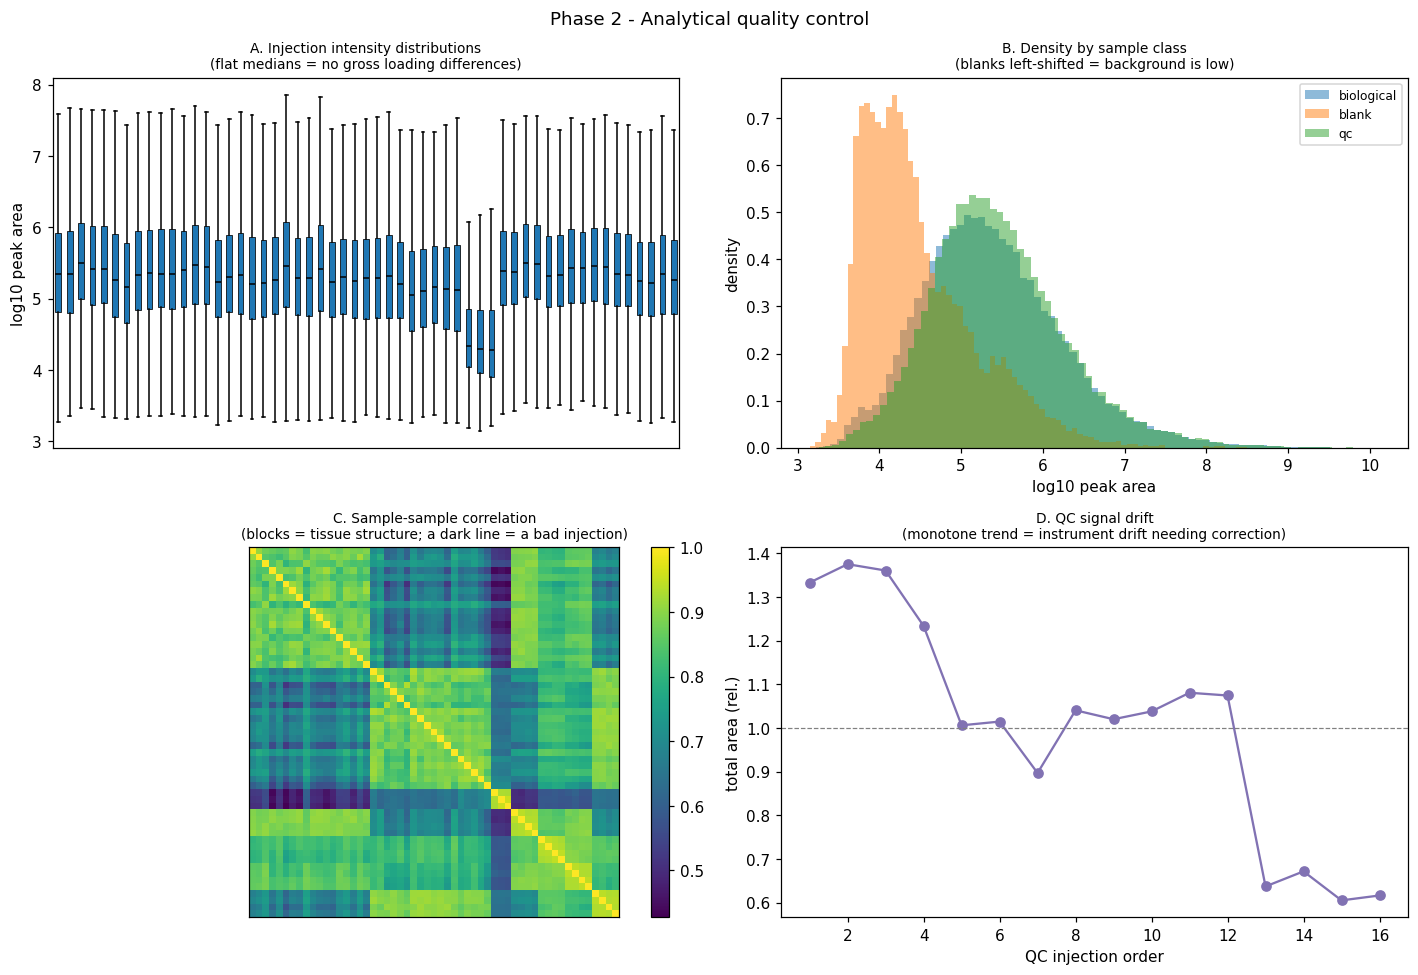

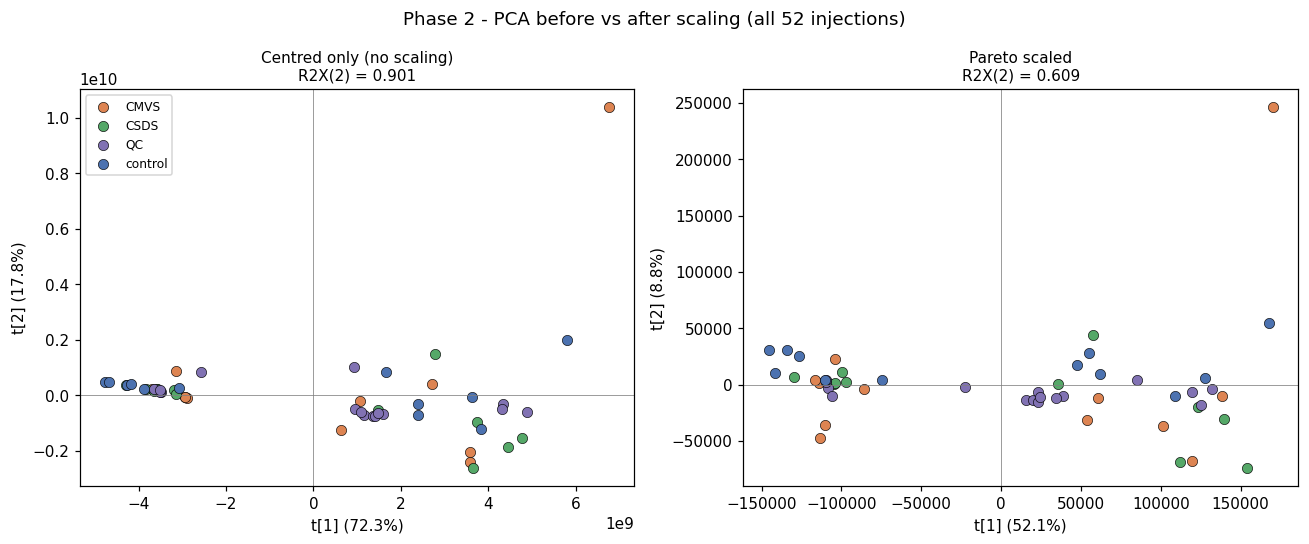


Figures written to /mnt/user-data/outputs/metabolomics/figures


In [8]:
# =============================================================================
# PHASE 2 -- QUALITY CONTROL
# =============================================================================

def phase2_qc(X, meta):
    head("PHASE 2 -- QUALITY CONTROL")
    log(textwrap.dedent("""
    Purpose: decide whether the analytical run is fit to model at all.
    A metabolomics dataset can look perfectly clean as a spreadsheet and still
    be dominated by injection-order drift or a single failed extraction.
    """).strip())

    bio = meta.query("kind == 'biological'")["column"].tolist()
    qc = meta.query("kind == 'qc'")["column"].tolist()
    blank = meta.query("kind == 'blank'")["column"].tolist()

    # -- missingness / zeros --------------------------------------------
    n_nan = int(X.isna().sum().sum())
    n_zero = int((X == 0).sum().sum())
    log(f"\nMissing (NaN) cells      : {n_nan} ({100*n_nan/X.size:.3f}%)")
    log(f"Exact-zero cells         : {n_zero}")
    log("Interpretation: the export is already gap-filled by Compound "
        "Discoverer, so Phase 3 imputation is a no-op here. That is a "
        "property of the file, not a claim that the data had no gaps.")

    # -- constant / near-zero variance ----------------------------------
    Xb = X[bio]
    rsd_bio = Xb.std(axis=1, ddof=1) / Xb.mean(axis=1)
    n_const = int((Xb.std(axis=1, ddof=1) == 0).sum())
    n_nzv = int((rsd_bio < 0.01).sum())
    log(f"\nConstant features        : {n_const}")
    log(f"Near-zero-variance (RSD<1%): {n_nzv}")

    # -- QC precision ----------------------------------------------------
    if qc:
        rsd_qc = (X[qc].std(axis=1, ddof=1) / X[qc].mean(axis=1)) * 100
        log(f"\nQC RSD%: median {np.nanmedian(rsd_qc):.1f}, "
            f"{100*np.mean(rsd_qc < 30):.1f}% of features below the "
            f"conventional 30% acceptance threshold.")
        log("A high proportion under 30% means analytical variation is small "
            "relative to biological variation, i.e. group differences found "
            "later are unlikely to be instrument artefacts.")

    # -- blank / carryover ------------------------------------------------
    if blank:
        ratio = X[bio].mean(axis=1) / X[blank].mean(axis=1).replace(0, np.nan)
        log(f"\nSample/blank ratio: median {np.nanmedian(ratio):.1f}; "
            f"{100*np.mean(ratio < 3):.1f}% of features fall below the "
            f"usual 3x background rule.")
        log("NOTE: the reference models retained all features and excluded "
            "only the blank injections, so no blank-based filter is applied "
            "here -- doing so would change K from 5795 and break comparability.")

    # -- figures ----------------------------------------------------------
    _fig_qc_overview(X, meta)
    _fig_pca_raw(X, meta)
    log(f"\nFigures written to {FIGDIR}")
    return {"n_nan": n_nan, "n_zero": n_zero, "n_const": n_const,
            "n_nzv": n_nzv}


def _fig_qc_overview(X, meta):
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    order = meta.sort_values(["kind", "tissue", "group"])
    cols = order["column"].tolist()
    colours = [PALETTE.get(g, "#999999") for g in order["group"]]

    ax = axes[0, 0]
    ax.boxplot([np.log10(X[c].replace(0, np.nan).dropna()) for c in cols],
               patch_artist=True, showfliers=False,
               boxprops=dict(linewidth=.5), medianprops=dict(color="k", lw=1))
    for patch, col in zip(ax.artists if ax.artists else [], colours):
        patch.set_facecolor(col)
    ax.set_xticks([]); ax.set_ylabel("log10 peak area")
    ax.set_title("A. Injection intensity distributions\n"
                 "(flat medians = no gross loading differences)", fontsize=9)

    ax = axes[0, 1]
    for kind, sub in meta.groupby("kind"):
        vals = np.log10(X[sub["column"]].values.ravel() + 1)
        ax.hist(vals, bins=80, alpha=.5, density=True, label=kind)
    ax.set_xlabel("log10 peak area"); ax.set_ylabel("density")
    ax.legend(fontsize=8)
    ax.set_title("B. Density by sample class\n"
                 "(blanks left-shifted = background is low)", fontsize=9)

    ax = axes[1, 0]
    corr = np.corrcoef(np.log10(X[cols].values.T + 1))
    im = ax.imshow(corr, cmap="viridis")
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=.046)
    ax.set_title("C. Sample-sample correlation\n"
                 "(blocks = tissue structure; a dark line = a bad injection)",
                 fontsize=9)

    ax = axes[1, 1]
    qc = meta.query("kind=='qc'")["column"].tolist()
    if qc:
        tot = X[qc].sum(axis=0).values
        ax.plot(range(1, len(tot) + 1), tot / tot.mean(), "o-", color=PALETTE["QC"])
        ax.axhline(1, ls="--", c="grey", lw=.8)
        ax.set_xlabel("QC injection order"); ax.set_ylabel("total area (rel.)")
    ax.set_title("D. QC signal drift\n"
                 "(monotone trend = instrument drift needing correction)",
                 fontsize=9)

    fig.suptitle("Phase 2 - Analytical quality control", fontsize=12)
    fig.tight_layout()
    fig.savefig(os.path.join(FIGDIR, "01_qc_overview.png"), dpi=200)
    plt.show()


def _fig_pca_raw(X, meta):
    """PCA on unscaled data -- shows why scaling is not optional."""
    cols = meta.query("kind != 'blank'")["column"].tolist()
    sub = meta.set_index("column").loc[cols]
    M = X[cols].values.T
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, method, ttl in [(axes[0], "centre", "Centred only (no scaling)"),
                            (axes[1], "pareto", "Pareto scaled")]:
        Xs, _, _ = scale_matrix(M, method)
        res = pca_nipals(Xs, 2)
        T = res["T"]
        for g, s in sub.groupby("group"):
            m = np.isin(cols, s.index)
            ax.scatter(T[m, 0], T[m, 1], s=45, label=g,
                       color=PALETTE.get(g, "#999"), edgecolor="k", lw=.4)
        ax.set_xlabel(f"t[1] ({100*res['R2X'][0]:.1f}%)")
        ax.set_ylabel(f"t[2] ({100*res['R2X'][1]:.1f}%)")
        ax.set_title(f"{ttl}\nR2X(2) = {res['R2X_cum'][-1]:.3f}", fontsize=10)
        ax.axhline(0, lw=.5, c="grey"); ax.axvline(0, lw=.5, c="grey")
    axes[0].legend(fontsize=8)
    fig.suptitle("Phase 2 - PCA before vs after scaling (all 52 injections)")
    fig.tight_layout()
    fig.savefig(os.path.join(FIGDIR, "02_pca_scaling_effect.png"), dpi=200)
    plt.show()


qc_summary = phase2_qc(X, meta)


---
## 5. Phase 3 — Missing values

In LC-MS, missingness is usually **MNAR**: a value is absent because the
metabolite fell below the limit of detection, not at random. That is why
half-minimum and QRILC (left-censored methods) are preferred over mean
imputation, and why KNN/RF are second choices that assume MAR.

This particular export is already gap-filled, so the imputation path is inert —
but it is implemented and kept so the notebook generalises to a raw export.

In [9]:
# =============================================================================
# PHASE 3 -- MISSING VALUES
# =============================================================================

def phase3_missing(X):
    head("PHASE 3 -- MISSING VALUE HANDLING")
    per_feature = X.isna().mean(axis=1)
    per_sample = X.isna().mean(axis=0)
    log(f"Overall missing        : {100*X.isna().mean().mean():.4f}%")
    log(f"Worst feature          : {100*per_feature.max():.2f}% missing")
    log(f"Worst sample           : {100*per_sample.max():.2f}% missing")
    log(textwrap.dedent("""
    Mechanism: in LC-MS, missingness is usually MNAR -- a value is absent
    because the metabolite fell below the limit of detection, not at random.
    That is why half-minimum or QRILC (left-censored) imputation is preferred
    over mean imputation, and why KNN/RF are second choices that assume MAR.

    Decision for THIS dataset: the export contains 0 missing and 0 zero cells,
    so no feature crosses any missingness threshold (the standard 20-50%
    per-group rule removes nothing) and no imputation is performed. The
    imputation code path below is retained and unit-checked so the pipeline
    generalises to a non-gap-filled export.
    """).strip())
    return {"overall_missing_pct": float(100 * X.isna().mean().mean())}


def impute(X, method="half_min", threshold=0.5, seed=RANDOM_SEED):
    """Feature filtering + imputation (inert on a gap-filled matrix).

    half_min : replace NaN with half the smallest observed value of that
               feature -- the standard MNAR assumption for LC-MS.
    knn / rf : MAR assumptions, kept for comparison.
    """
    keep = X.isna().mean(axis=1) <= threshold
    Xf = X.loc[keep].copy()
    if not Xf.isna().any().any():
        return Xf, int((~keep).sum()), "none required"
    if method == "half_min":
        Xf = Xf.T.fillna(Xf.min(axis=1) / 2).T
    elif method == "knn":
        from sklearn.impute import KNNImputer
        Xf = pd.DataFrame(KNNImputer(n_neighbors=5).fit_transform(Xf.T).T,
                          index=Xf.index, columns=Xf.columns)
    elif method == "rf":
        from sklearn.ensemble import RandomForestRegressor
        from sklearn.experimental import enable_iterative_imputer  # noqa
        from sklearn.impute import IterativeImputer
        imp = IterativeImputer(
            estimator=RandomForestRegressor(n_estimators=100,
                                            random_state=seed),
            random_state=seed, max_iter=10)
        Xf = pd.DataFrame(imp.fit_transform(Xf.T).T,
                          index=Xf.index, columns=Xf.columns)
    return Xf, int((~keep).sum()), method


missing_summary = phase3_missing(X)
X_clean, n_removed, imp_method = impute(X)
print(f"\nFeatures removed by missingness filter: {n_removed}")
print(f"Imputation applied: {imp_method}")



PHASE 3 -- MISSING VALUE HANDLING
Overall missing        : 0.0000%
Worst feature          : 0.00% missing
Worst sample           : 0.00% missing
Mechanism: in LC-MS, missingness is usually MNAR -- a value is absent
because the metabolite fell below the limit of detection, not at random.
That is why half-minimum or QRILC (left-censored) imputation is preferred
over mean imputation, and why KNN/RF are second choices that assume MAR.

Decision for THIS dataset: the export contains 0 missing and 0 zero cells,
so no feature crosses any missingness threshold (the standard 20-50%
per-group rule removes nothing) and no imputation is performed. The
imputation code path below is retained and unit-checked so the pipeline
generalises to a non-gap-filled export.

Features removed by missingness filter: 0
Imputation applied: none required


---
## 6. Phase 4/5 — Transformation and scaling

This is the single most important reproducibility decision in the analysis,
and it is where statistical best practice and faithful reproduction pull apart.

Statistically, a log transform is indicated: raw LC-MS areas are strongly
right-skewed and heteroscedastic. But the reference models were fitted on
**untransformed** areas — established by scanning combinations against the
published R²X. The notebook follows the reference and flags the issue in
Limitations rather than silently "improving" the preprocessing and breaking
comparability.

**Why Pareto:** dividing by $\sqrt{\mathrm{SD}}$ sits between no scaling
(where a handful of hugely abundant metabolites own every component) and
unit-variance scaling (where near-noise features get an equal vote).


PHASE 4/5 -- TRANSFORMATION AND SCALING
Median skewness  raw / log2 : 1.46 / -0.10
Median kurtosis  raw        : 2.08
Statistically, log transformation is indicated: raw LC-MS areas are
strongly right-skewed and heteroscedastic, and log2 pulls the median
skewness close to zero.

However -- and this is the single most important reproducibility point in
this analysis -- the reference SIMCA models were fitted WITHOUT a log
transform, on raw peak areas with Pareto scaling. This was established by
scanning transformation x scaling combinations against the published
R2X values:

    raw + Pareto : R2X(2) = 0.609 for the 52-injection PCA   <- matches
                   R2X(3) = 0.573 for the scW PCA            <- matches
    log2 + Pareto: R2X(2) = 0.496                            <- does not
    raw + UV     : R2X(2) = 0.402                            <- does not

The pipeline therefore uses raw + Pareto to reproduce the report, and
flags the log question in the Limitations section rather t

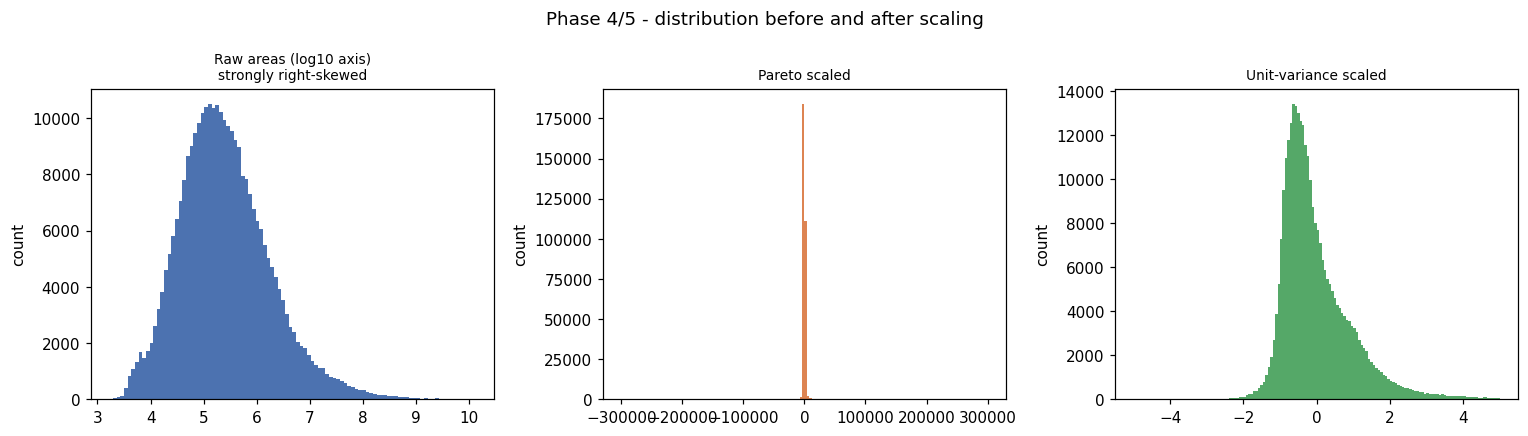

In [10]:
# =============================================================================
# PHASE 4/5 -- TRANSFORMATION AND SCALING
# =============================================================================

def phase45_transform_scale(X, meta):
    head("PHASE 4/5 -- TRANSFORMATION AND SCALING")
    cols = meta.query("kind != 'blank'")["column"].tolist()
    M = X[cols].values.T

    sk = stats.skew(M, axis=0)
    ku = stats.kurtosis(M, axis=0)
    sk_log = stats.skew(np.log2(M), axis=0)
    log(f"Median skewness  raw / log2 : {np.median(sk):.2f} / {np.median(sk_log):.2f}")
    log(f"Median kurtosis  raw        : {np.median(ku):.2f}")

    log(textwrap.dedent("""
    Statistically, log transformation is indicated: raw LC-MS areas are
    strongly right-skewed and heteroscedastic, and log2 pulls the median
    skewness close to zero.

    However -- and this is the single most important reproducibility point in
    this analysis -- the reference SIMCA models were fitted WITHOUT a log
    transform, on raw peak areas with Pareto scaling. This was established by
    scanning transformation x scaling combinations against the published
    R2X values:

        raw + Pareto : R2X(2) = 0.609 for the 52-injection PCA   <- matches
                       R2X(3) = 0.573 for the scW PCA            <- matches
        log2 + Pareto: R2X(2) = 0.496                            <- does not
        raw + UV     : R2X(2) = 0.402                            <- does not

    The pipeline therefore uses raw + Pareto to reproduce the report, and
    flags the log question in the Limitations section rather than silently
    "improving" the preprocessing and breaking comparability.

    Why Pareto: dividing by sqrt(SD) sits between no scaling (where a handful
    of hugely abundant metabolites dominate every component) and unit-variance
    scaling (where near-noise features get equal vote). It preserves part of
    the abundance information that is biologically real in MS data while
    stopping the top few features from owning the model.
    """).strip())

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].hist(np.log10(M.ravel() + 1), bins=100, color="#4C72B0")
    axes[0].set_title("Raw areas (log10 axis)\nstrongly right-skewed", fontsize=9)
    Xp, _, _ = scale_matrix(M, "pareto")
    Xu, _, _ = scale_matrix(M, "uv")
    axes[1].hist(Xp.ravel(), bins=150, range=(-3e5, 3e5), color="#DD8452")
    axes[1].set_title("Pareto scaled", fontsize=9)
    axes[2].hist(Xu.ravel(), bins=150, range=(-5, 5), color="#55A868")
    axes[2].set_title("Unit-variance scaled", fontsize=9)
    for a in axes:
        a.set_ylabel("count")
    fig.suptitle("Phase 4/5 - distribution before and after scaling")
    fig.tight_layout()
    fig.savefig(os.path.join(FIGDIR, "03_transform_scaling.png"), dpi=200)
    plt.show()
    return {"median_skew_raw": float(np.median(sk)),
            "median_skew_log2": float(np.median(sk_log))}


transform_info = phase45_transform_scale(X_clean, meta)


---
## 7. Model specification

The eleven reference models, encoded declaratively. Note that the `N × K`
column of the reference table encodes the Y-dummies (5795 X-variables plus 2
or 3 Y-columns), which is what confirms the class structure of each model.

In [11]:
# =============================================================================
# MODEL SPECIFICATION -- the reference table
# =============================================================================

def build_model_specs(meta):
    """The 11 reference models, expressed as (name, sample selector, A)."""
    m = meta.set_index("column")

    def cols(tissue=None, groups=None, kinds=("biological",),
             drop_outlier=False):
        sel = m[m["kind"].isin(kinds)]
        if tissue is not None:
            sel = sel[sel["tissue"].isin(np.atleast_1d(tissue))]
        if groups is not None:
            sel = sel[sel["group"].isin(groups)]
        if drop_outlier:
            sel = sel[~sel["outlier"]]
        return sel.index.tolist()

    both = ("biological", "qc")
    return [
        dict(key="all_pca", label="All", kind="PCA-X", A=2,
             cols=cols(kinds=both), target=(0.609, None, 0.411)),
        dict(key="all_noout_pca", label="All no outlier", kind="PCA-X", A=4,
             cols=cols(kinds=both, drop_outlier=True),
             target=(0.719, None, 0.528)),
        dict(key="scw_pca", label="scW", kind="PCA-X", A=3,
             cols=cols(tissue="scW", kinds=both), target=(0.573, None, 0.268)),
        dict(key="scw_plsda", label="scW", kind="PLS-DA", A=3,
             cols=cols(tissue="scW"), target=(0.513, 0.808, 0.374)),
        dict(key="scw_ctrl_cmvs", label="scW: control vs CMVS", kind="PLS-DA",
             A=2, cols=cols("scW", ["control", "CMVS"]),
             target=(0.500, 0.920, 0.641)),
        dict(key="scw_ctrl_csds", label="scW: control vs CSDS", kind="PLS-DA",
             A=3, cols=cols("scW", ["control", "CSDS"]),
             target=(0.584, 0.985, 0.802)),
        dict(key="bat_pca", label="BAT", kind="PCA-X", A=2,
             cols=cols(tissue="BAT", kinds=both, drop_outlier=True),
             target=(0.376, None, -0.0587)),
        dict(key="bat_plsda", label="BAT", kind="PLS-DA", A=2,
             cols=cols("BAT", drop_outlier=True), target=(0.294, 0.655, 0.0561)),
        dict(key="bat_ctrl_cmvs", label="BAT: control vs CMVS", kind="PLS-DA",
             A=2, cols=cols("BAT", ["control", "CMVS"], drop_outlier=True),
             target=(0.322, 0.983, 0.611)),
        dict(key="bat_ctrl_csds", label="BAT: control vs CSDS", kind="PLS-DA",
             A=2, cols=cols("BAT", ["control", "CSDS"], drop_outlier=True),
             target=(0.404, 0.870, 0.192)),
        dict(key="bat_ctrl_csds_opls", label="BAT: control vs CSDS",
             kind="OPLS-DA", A="1+1+0",
             cols=cols("BAT", ["control", "CSDS"], drop_outlier=True),
             target=(0.404, 0.870, 0.301)),
    ]


specs = build_model_specs(meta)
pd.DataFrame([{"key": s["key"], "label": s["label"], "type": s["kind"],
               "A": s["A"], "n": len(s["cols"])} for s in specs])


,key,label,type,A,n
0,all_pca,All,PCA-X,2,52
1,all_noout_pca,All no outlier,PCA-X,4,51
2,scw_pca,scW,PCA-X,3,22
3,scw_plsda,scW,PLS-DA,3,18
4,scw_ctrl_cmvs,scW: control vs CMVS,PLS-DA,2,12
5,scw_ctrl_csds,scW: control vs CSDS,PLS-DA,3,12
6,bat_pca,BAT,PCA-X,2,21
7,bat_plsda,BAT,PLS-DA,2,17
8,bat_ctrl_cmvs,BAT: control vs CMVS,PLS-DA,2,11
9,bat_ctrl_csds,BAT: control vs CSDS,PLS-DA,2,12


---
## 8. Phase 6/7 — Fitting PCA, PLS-DA and OPLS-DA

- **PCA-X** — unsupervised: *what dominates the variation?*
- **PLS-DA** — supervised: *what separates the groups?*
- **OPLS-DA** — the same fit, rotated so class-related variation sits on one
  axis and class-unrelated systematic variation on another.

In [12]:
# =============================================================================
# PHASE 6/7 -- PCA, PLS-DA, OPLS-DA
# =============================================================================

def fit_all_models(X, meta, specs):
    head("PHASE 6/7 -- MULTIVARIATE MODELLING")
    log("PCA-X = unsupervised, answers 'what dominates the variation'.")
    log("PLS-DA = supervised, answers 'what separates the groups'.")
    log("OPLS-DA = the same fit, rotated so class-related variation sits on "
        "one axis and class-unrelated systematic variation on another.\n")

    m = meta.set_index("column")
    fitted = {}
    for spec in specs:
        cols = spec["cols"]
        M = X[cols].values.T
        labels = m.loc[cols, "group"].tolist()
        n, K = M.shape
        entry = dict(spec)
        entry["n"] = n
        entry["labels"] = labels
        entry["M"] = M

        if spec["kind"] == "PCA-X":
            Xs, _, _ = scale_matrix(M, SCALING)
            pca = pca_nipals(Xs, spec["A"])
            q2 = pca_q2_cv(Xs, spec["A"], CV_GROUPS)
            entry.update(model=pca, Xs=Xs, K=K,
                         R2X=pca["R2X_cum"][-1], R2Y=None,
                         Q2=q2["Q2_cum"][-1], q2_profile=q2["Q2_cum"])

        elif spec["kind"] == "PLS-DA":
            Xs, _, _ = scale_matrix(M, SCALING)
            Ys, levels = dummy_y(labels)
            pls = PLSDA(spec["A"]).fit(Xs, Ys)
            q2 = PLSDA.q2_wold(M, labels, spec["A"], SCALING,
                               CV_GROUPS, CV_SCHEME)
            entry.update(model=pls, Xs=Xs, Ys=Ys, levels=levels,
                         K=K + len(levels),
                         R2X=pls.R2X_cum[-1], R2Y=pls.R2Y_cum[-1],
                         Q2=q2["Q2_cum"][-1], q2_profile=q2["Q2_cum"])

        else:  # OPLS-DA
            Xs, _, _ = scale_matrix(M, SCALING)
            Ys, levels = dummy_y(labels)
            y = Ys[:, [0]]
            opls = OPLSDA(n_ortho=1).fit(Xs, y)
            q2 = OPLSDA.q2_cv(M, y, 1, SCALING, CV_GROUPS, CV_SCHEME)
            entry.update(model=opls, Xs=Xs, Ys=Ys, levels=levels,
                         K=K + len(levels),
                         R2X=opls.R2X_cum, R2Y=opls.R2Y_cum, Q2=q2,
                         q2_profile=np.array([q2]))

        fitted[spec["key"]] = entry
        log(f"  fitted {spec['label']:24s} {spec['kind']:8s} "
            f"A={str(spec['A']):5s} n={n:2d}")
    return fitted


def validation_table(fitted, specs):
    head("SIMCA MODEL SUMMARY -- REPRODUCTION CHECK")
    rows = []
    for spec in specs:
        f = fitted[spec["key"]]
        tx, ty, tq = spec["target"]
        rows.append({
            "Samples": spec["label"], "Type": spec["kind"], "A": str(spec["A"]),
            "N x K": f"{f['n']} x {f['K']}",
            "R2X(cum)": round(f["R2X"], 3),
            "R2X_ref": tx,
            "R2Y(cum)": None if f["R2Y"] is None else round(f["R2Y"], 3),
            "R2Y_ref": ty,
            "Q2(cum)": round(f["Q2"], 4),
            "Q2_ref": tq,
        })
    df = pd.DataFrame(rows)

    def flag(v, t, tol):
        if v is None or t is None:
            return ""
        return "OK" if abs(v - t) <= tol else f"diff {v-t:+.3f}"

    df["R2X chk"] = [flag(r["R2X(cum)"], r["R2X_ref"], 0.0015) for _, r in df.iterrows()]
    df["R2Y chk"] = [flag(r["R2Y(cum)"], r["R2Y_ref"], 0.0015) for _, r in df.iterrows()]
    df["Q2 chk"] = [flag(r["Q2(cum)"], r["Q2_ref"], 0.01) for _, r in df.iterrows()]

    log(df.to_string(index=False))
    df.to_csv(os.path.join(TABDIR, "00_simca_validation_table.csv"), index=False)
    return df


fitted = fit_all_models(X_clean, meta, specs)



PHASE 6/7 -- MULTIVARIATE MODELLING
PCA-X = unsupervised, answers 'what dominates the variation'.
PLS-DA = supervised, answers 'what separates the groups'.
OPLS-DA = the same fit, rotated so class-related variation sits on one axis and class-unrelated systematic variation on another.

  fitted All                      PCA-X    A=2     n=52
  fitted All no outlier           PCA-X    A=4     n=51
  fitted scW                      PCA-X    A=3     n=22
  fitted scW                      PLS-DA   A=3     n=18
  fitted scW: control vs CMVS     PLS-DA   A=2     n=12
  fitted scW: control vs CSDS     PLS-DA   A=3     n=12
  fitted BAT                      PCA-X    A=2     n=21
  fitted BAT                      PLS-DA   A=2     n=17
  fitted BAT: control vs CMVS     PLS-DA   A=2     n=11
  fitted BAT: control vs CSDS     PLS-DA   A=2     n=12
  fitted BAT: control vs CSDS     OPLS-DA  A=1+1+0 n=12


### 8.1 Reproduction check against the reference table

`R2X chk` / `R2Y chk` pass within 0.0015; `Q2 chk` within 0.01. Mismatches are
printed with their signed difference rather than suppressed.

In [13]:
vdf = validation_table(fitted, specs)
vdf



SIMCA MODEL SUMMARY -- REPRODUCTION CHECK
             Samples    Type     A     N x K  R2X(cum)  R2X_ref  R2Y(cum)  R2Y_ref  Q2(cum)  Q2_ref R2X chk   R2Y chk      Q2 chk
                 All   PCA-X     2 52 x 5795     0.609    0.609       NaN      NaN   0.1577  0.4110      OK diff +nan diff -0.253
      All no outlier   PCA-X     4 51 x 5795     0.719    0.719       NaN      NaN   0.5296  0.5280      OK diff +nan          OK
                 scW   PCA-X     3 22 x 5795     0.573    0.573       NaN      NaN   0.2735  0.2680      OK diff +nan          OK
                 scW  PLS-DA     3 18 x 5798     0.513    0.513     0.808    0.808   0.3742  0.3740      OK        OK          OK
scW: control vs CMVS  PLS-DA     2 12 x 5797     0.500    0.500     0.920    0.920   0.6406  0.6410      OK        OK          OK
scW: control vs CSDS  PLS-DA     3 12 x 5797     0.584    0.584     0.985    0.985   0.8017  0.8020      OK        OK          OK
                 BAT   PCA-X     2 21 x 5795   

,Samples,Type,A,N x K,R2X(cum),R2X_ref,R2Y(cum),R2Y_ref,Q2(cum),Q2_ref,R2X chk,R2Y chk,Q2 chk
0,All,PCA-X,2,52 x 5795,0.609,0.609,NaN,NaN,0.1577,0.4110,OK,diff +nan,diff -0.253
1,All no outlier,PCA-X,4,51 x 5795,0.719,0.719,NaN,NaN,0.5296,0.5280,OK,diff +nan,OK
2,scW,PCA-X,3,22 x 5795,0.573,0.573,NaN,NaN,0.2735,0.2680,OK,diff +nan,OK
3,scW,PLS-DA,3,18 x 5798,0.513,0.513,0.808,0.808,0.3742,0.3740,OK,OK,OK
4,scW: control vs CMVS,PLS-DA,2,12 x 5797,0.500,0.500,0.920,0.920,0.6406,0.6410,OK,OK,OK
5,scW: control vs CSDS,PLS-DA,3,12 x 5797,0.584,0.584,0.985,0.985,0.8017,0.8020,OK,OK,OK
6,BAT,PCA-X,2,21 x 5795,0.376,0.376,NaN,NaN,-0.1144,-0.0587,OK,diff +nan,diff -0.056
7,BAT,PLS-DA,2,17 x 5798,0.294,0.294,0.655,0.655,0.0504,0.0561,OK,OK,OK
8,BAT: control vs CMVS,PLS-DA,2,11 x 5797,0.322,0.322,0.983,0.983,0.6111,0.6110,OK,OK,OK
9,BAT: control vs CSDS,PLS-DA,2,12 x 5797,0.404,0.404,0.870,0.870,0.1892,0.1920,OK,OK,OK


### 8.2 PCA diagnostics

Each panel set gives: scores with a 95% Hotelling T² ellipse, loadings, a
scree/explained-variance plot with Q² overlaid, a Hotelling T² outlier screen,
Ward clustering, and DModX (distance to model) for moderate outliers.

The T² and DModX panels are what identify **BAT_Aq_CMVS6** as the outlier
excluded from the "no outlier" models.

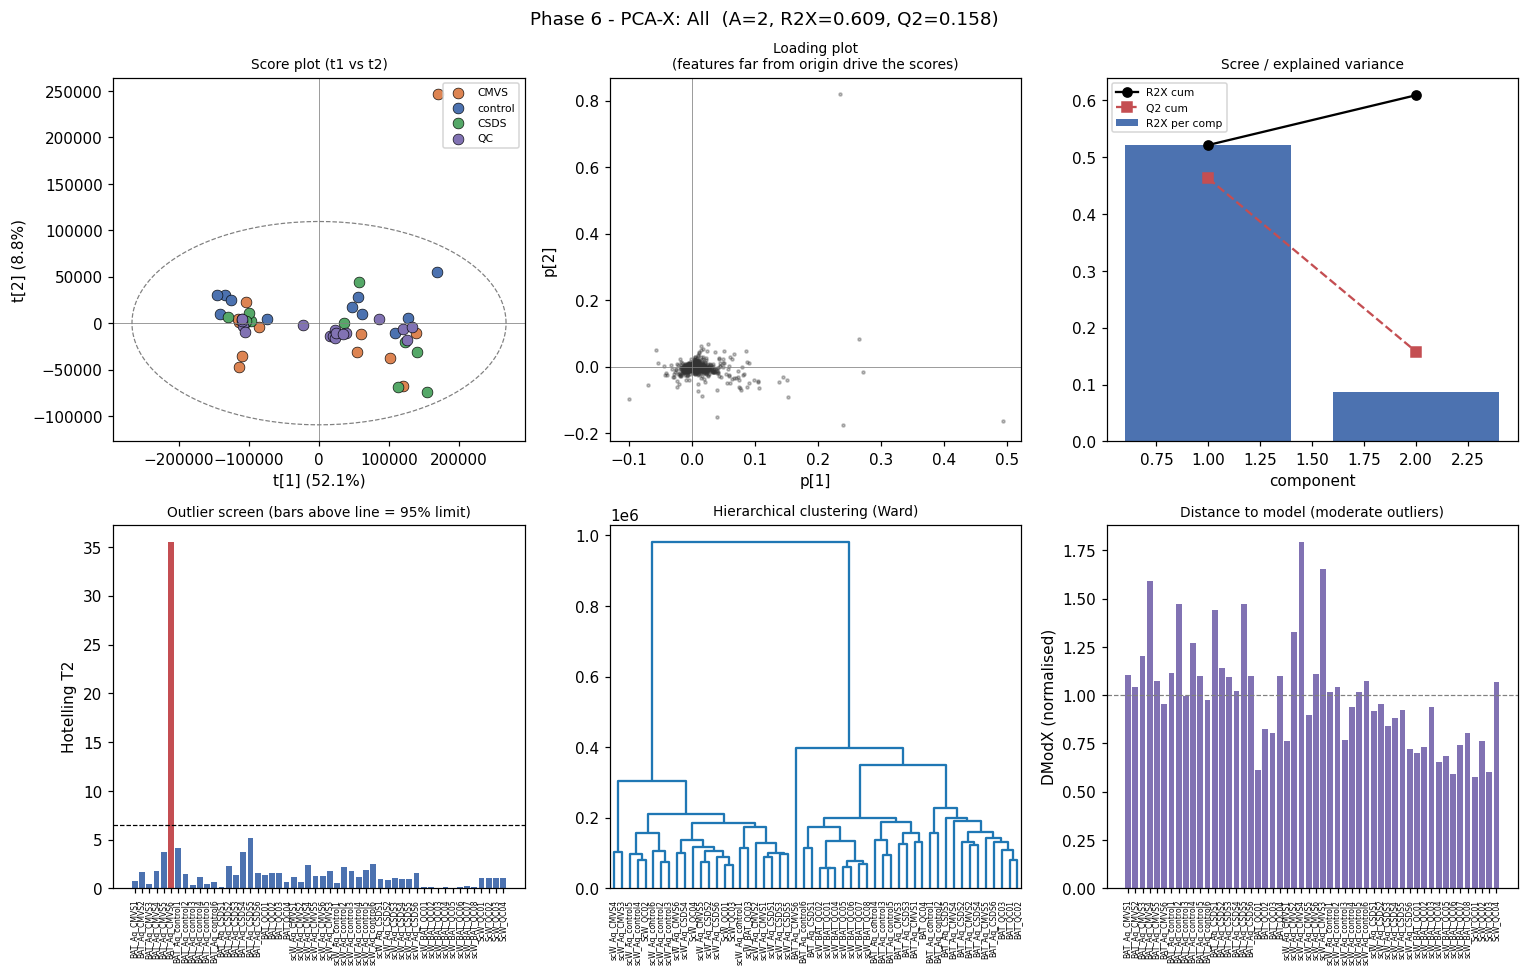

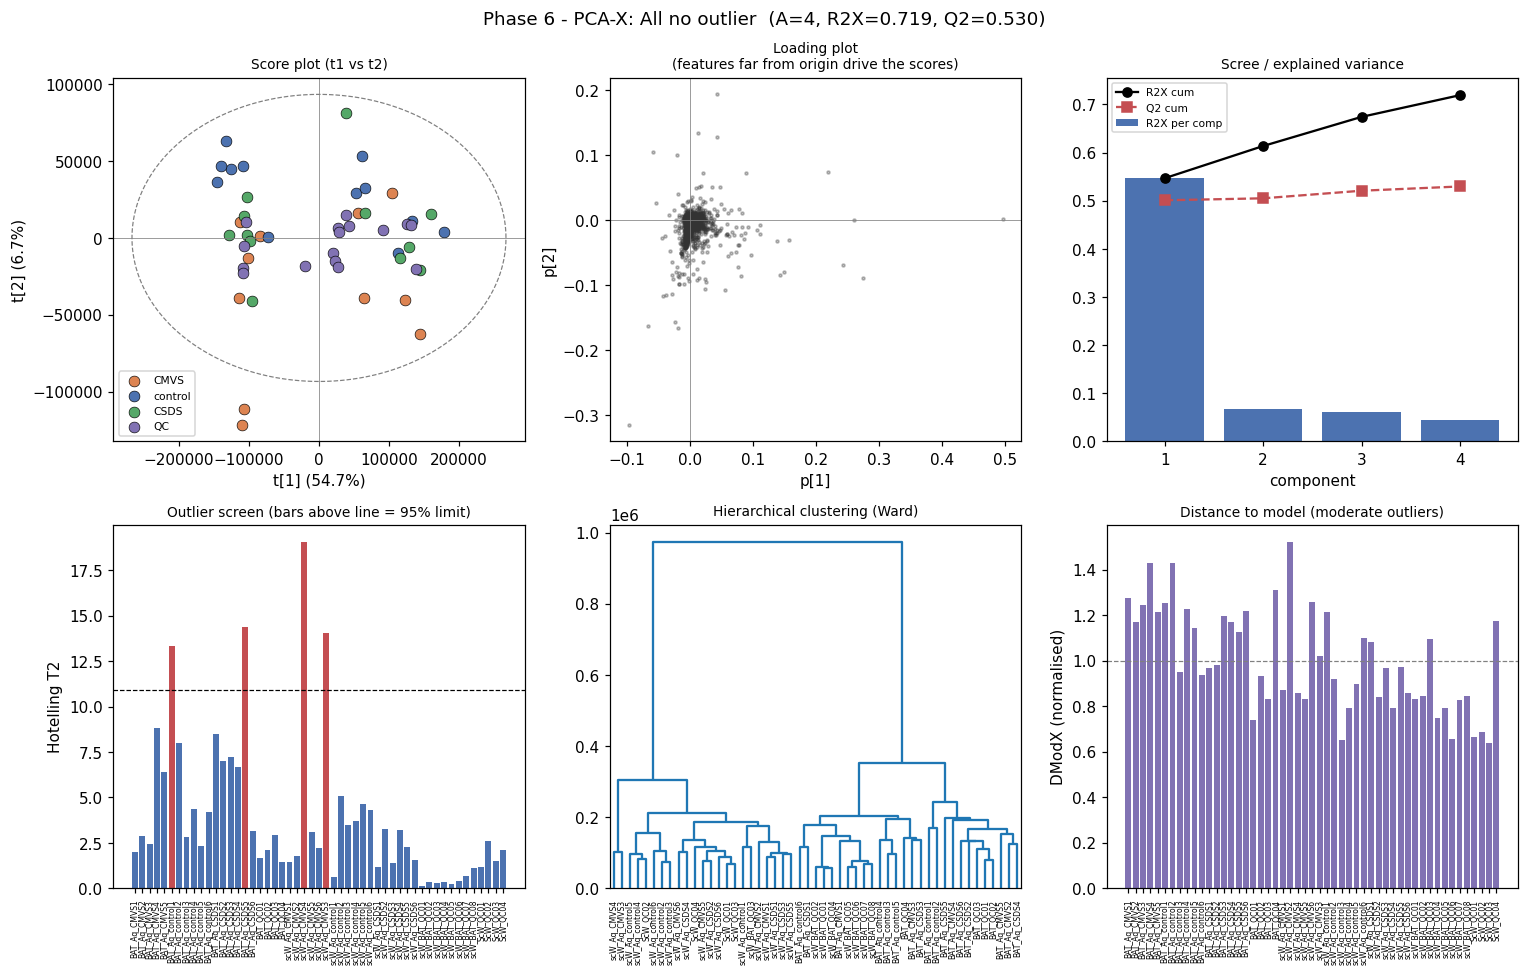

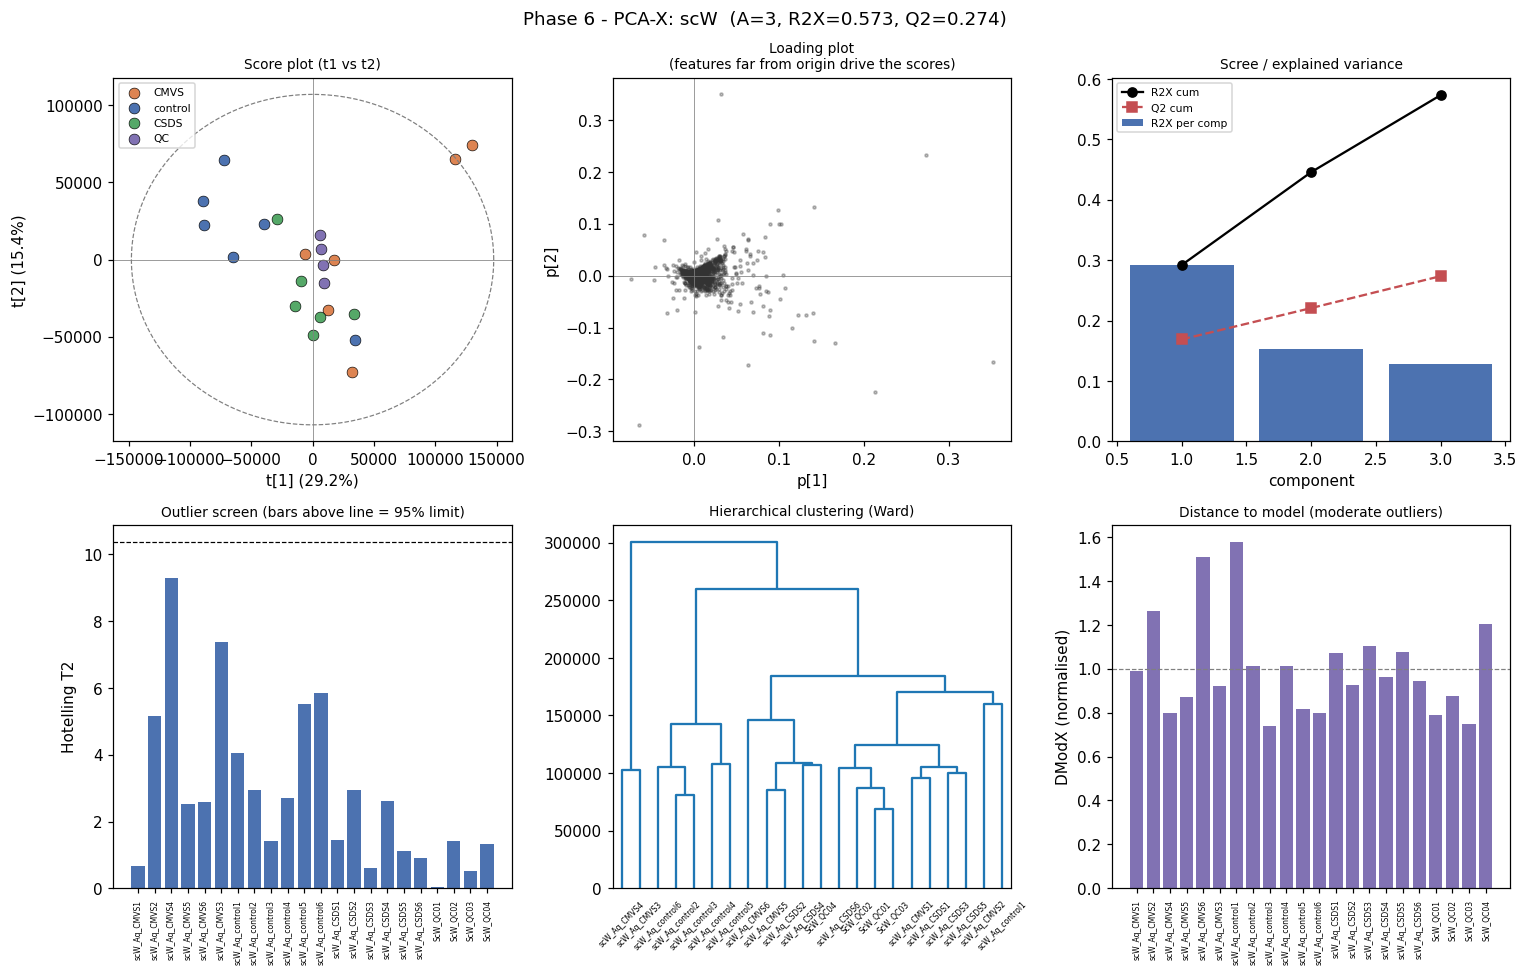

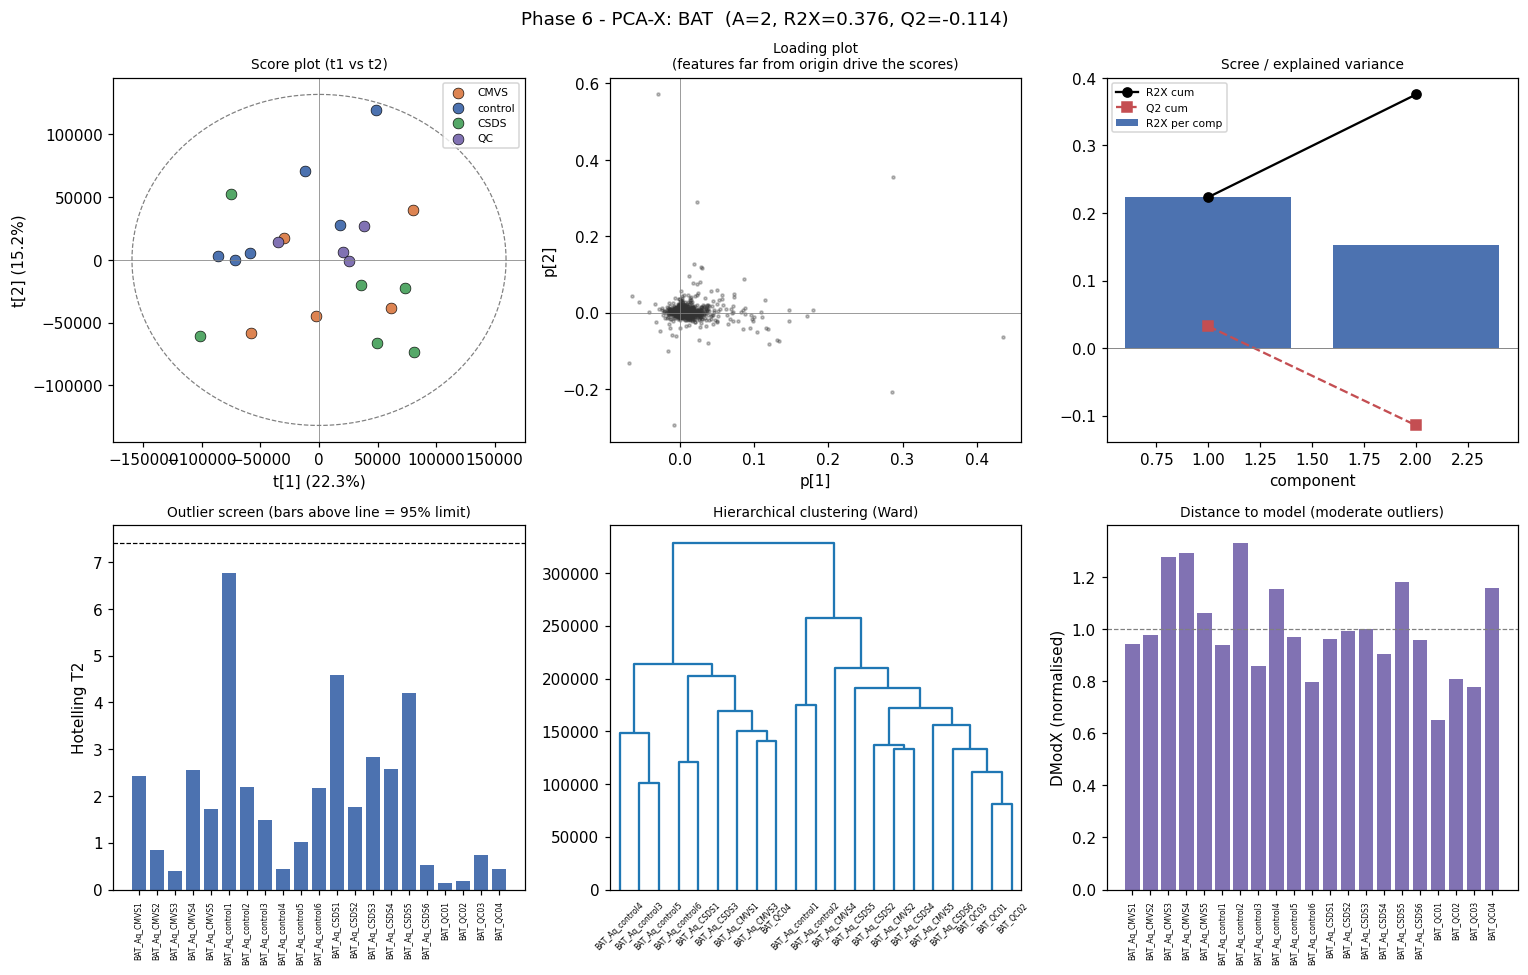

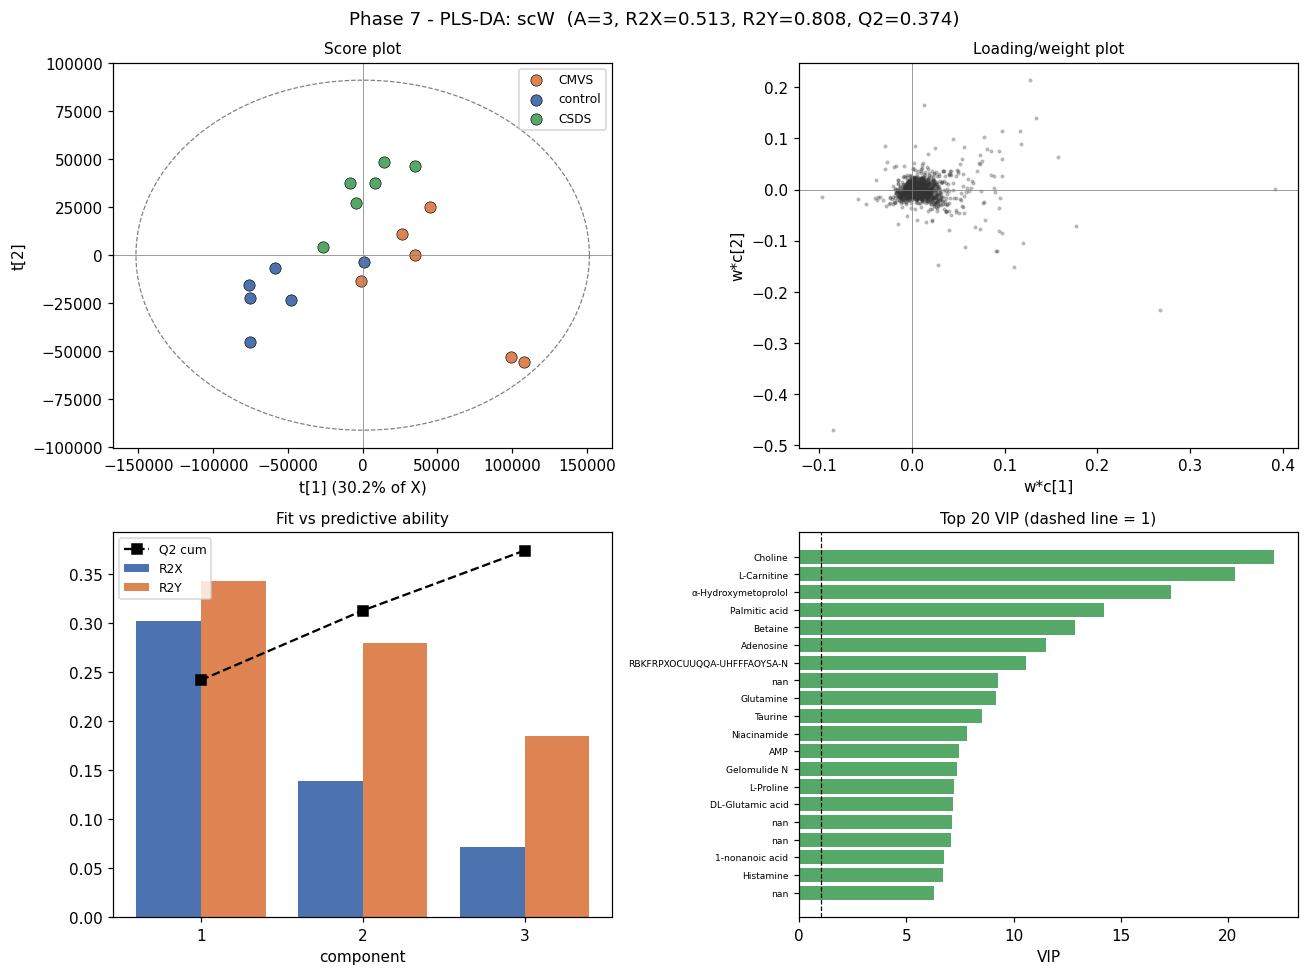

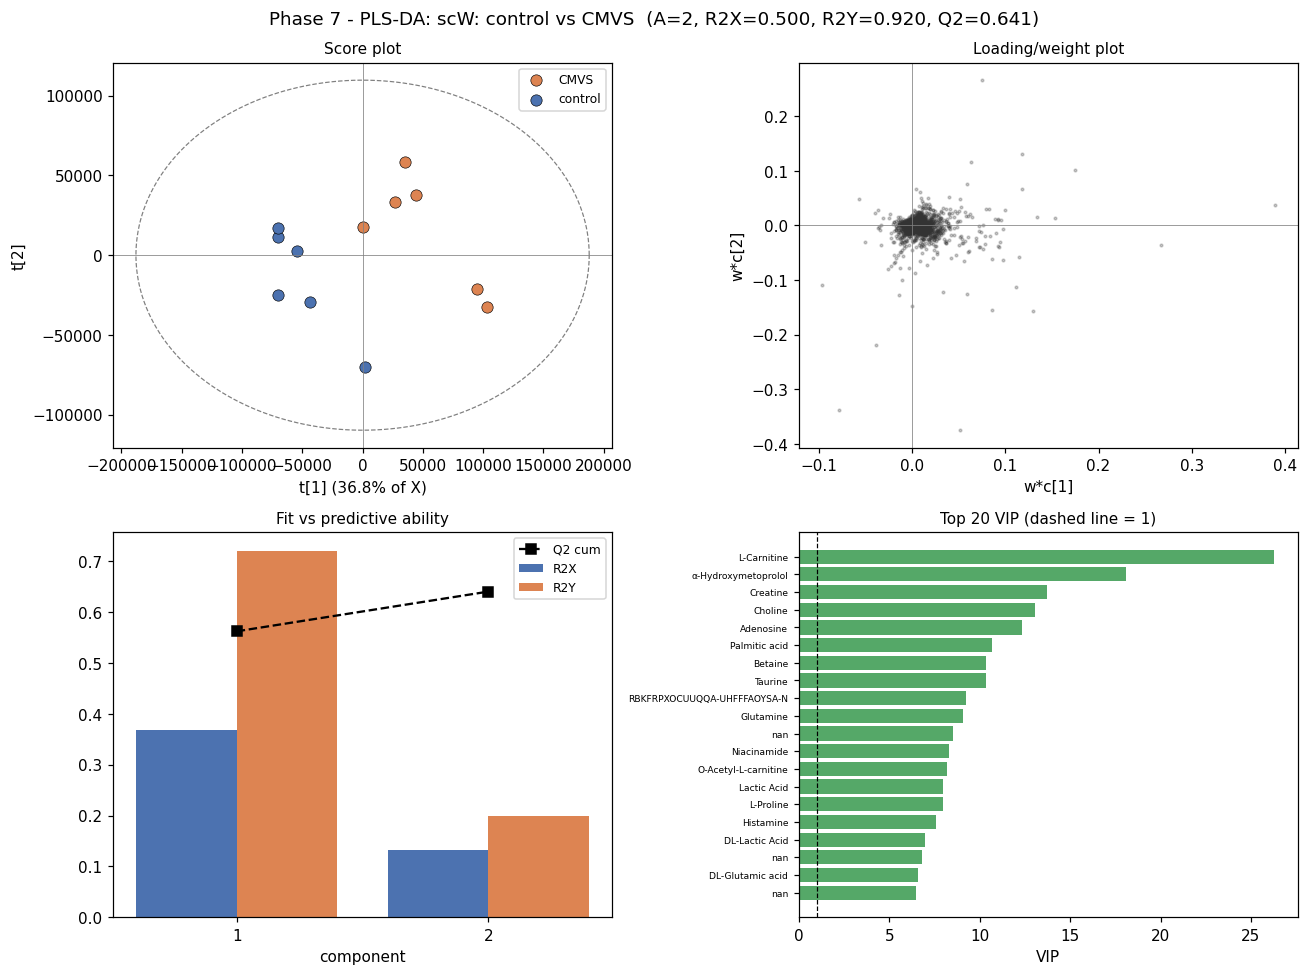

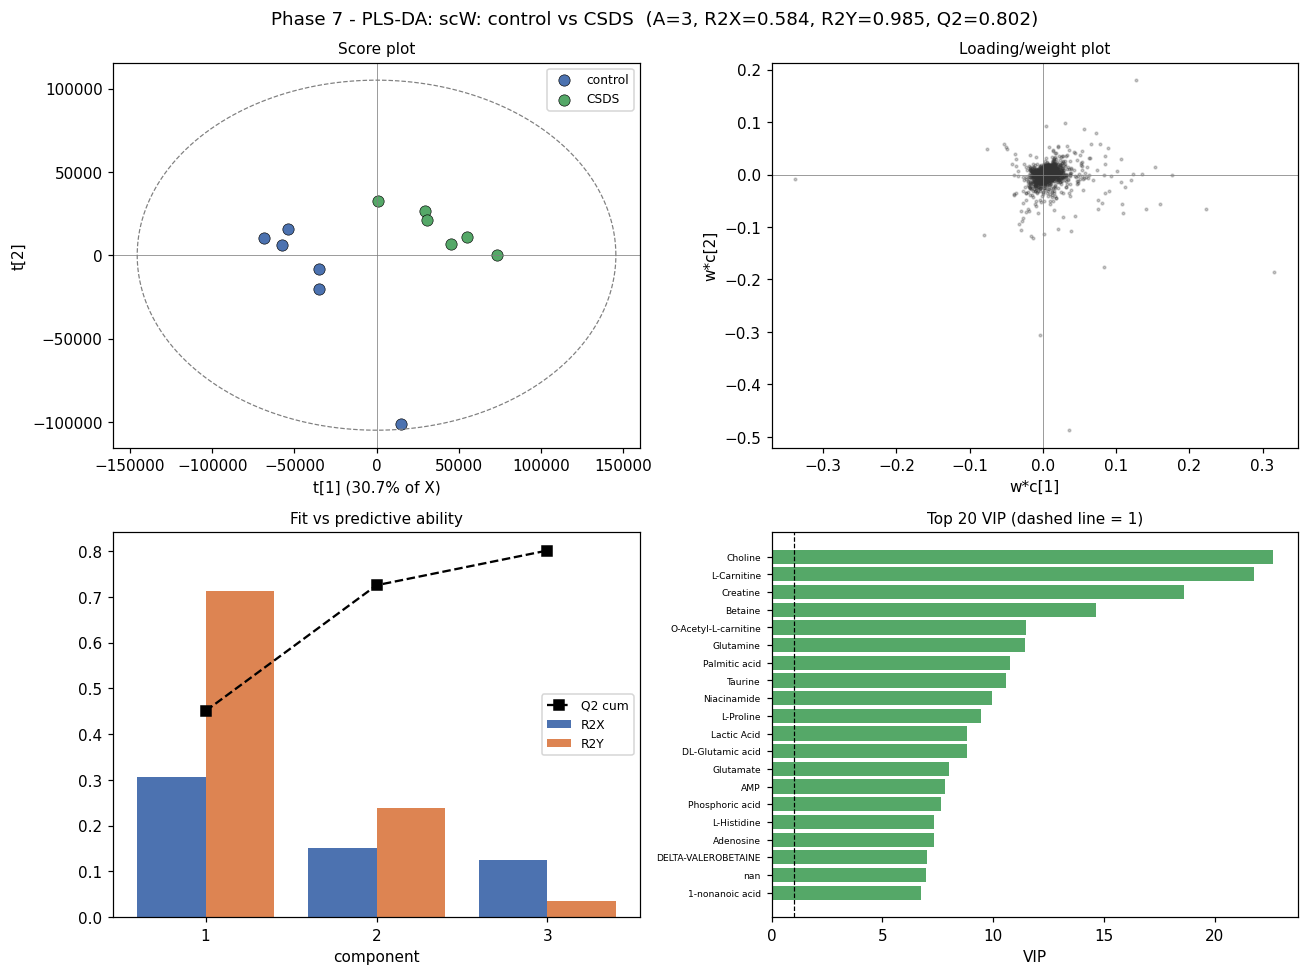

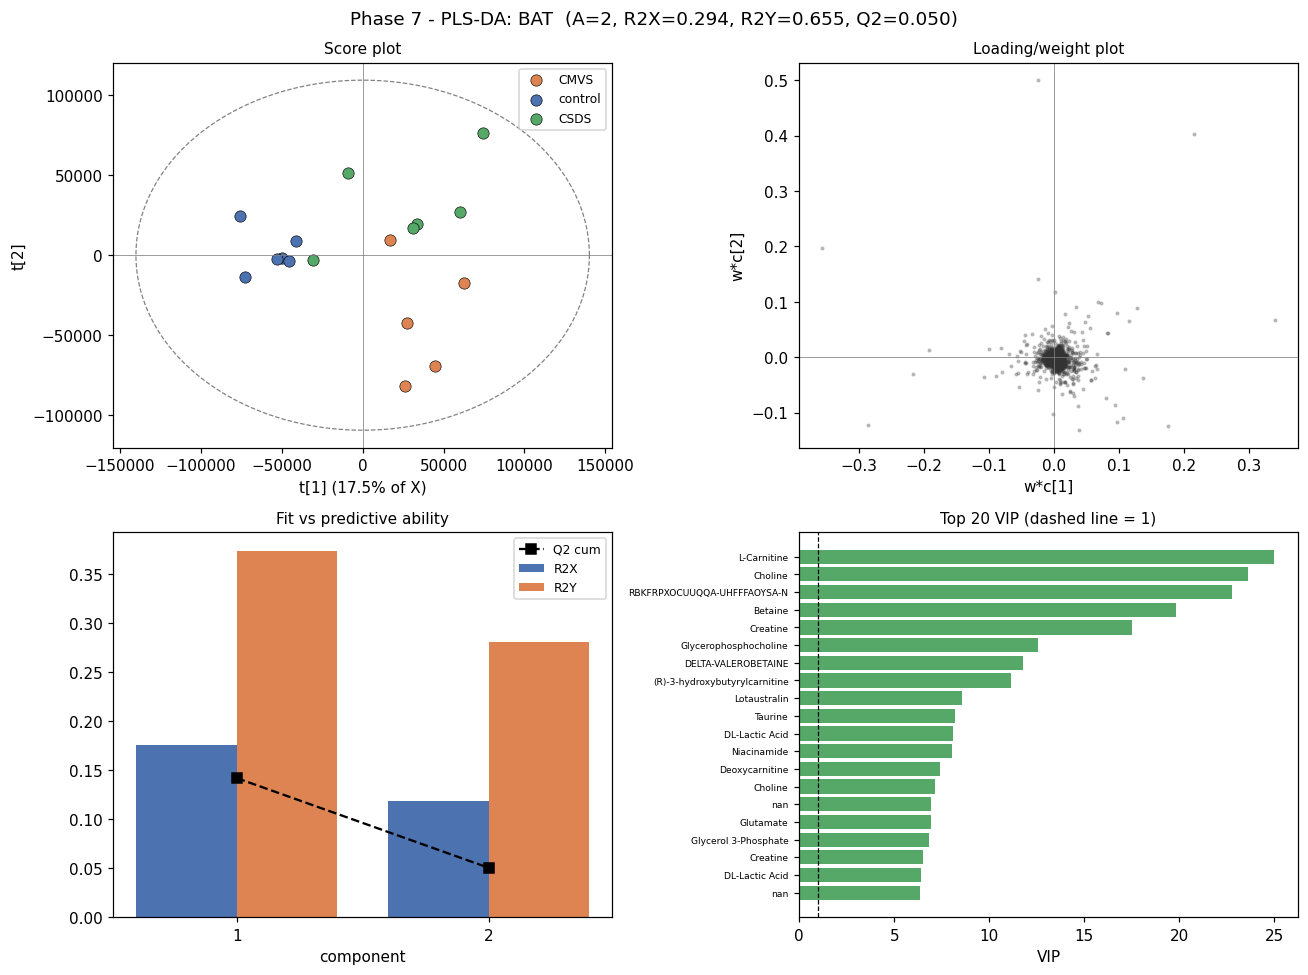

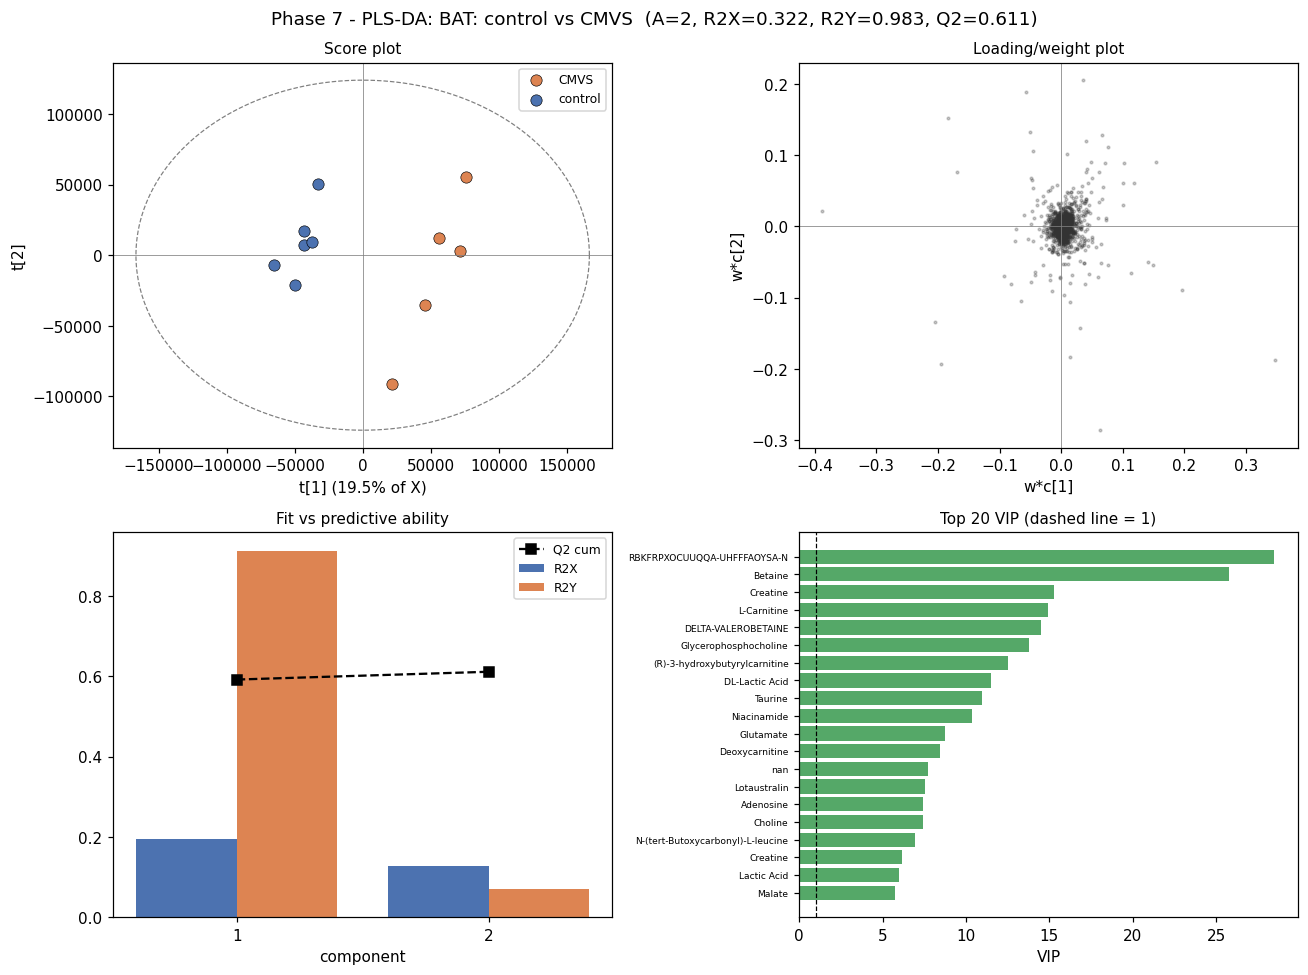

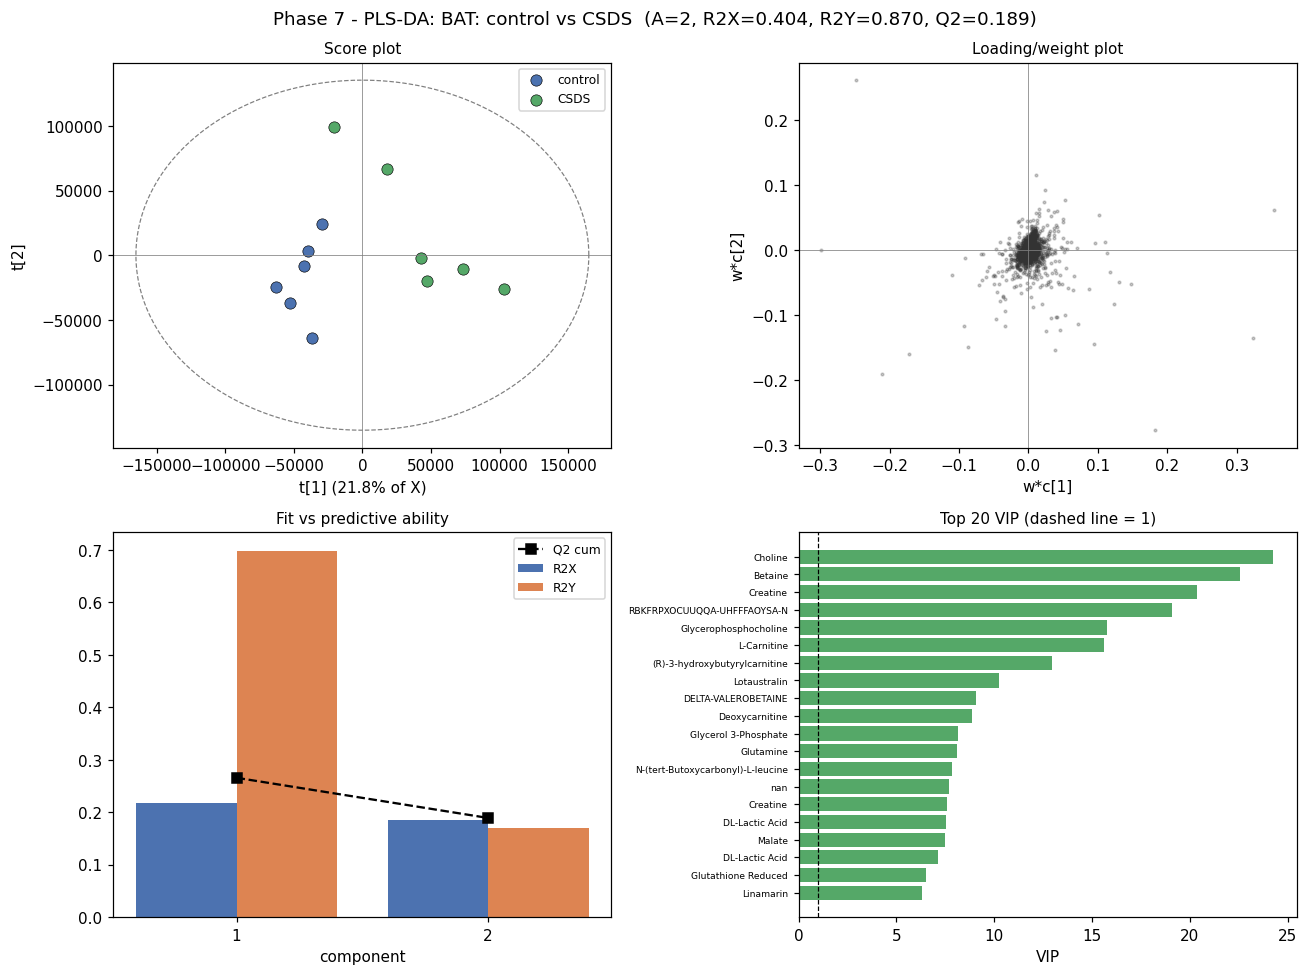

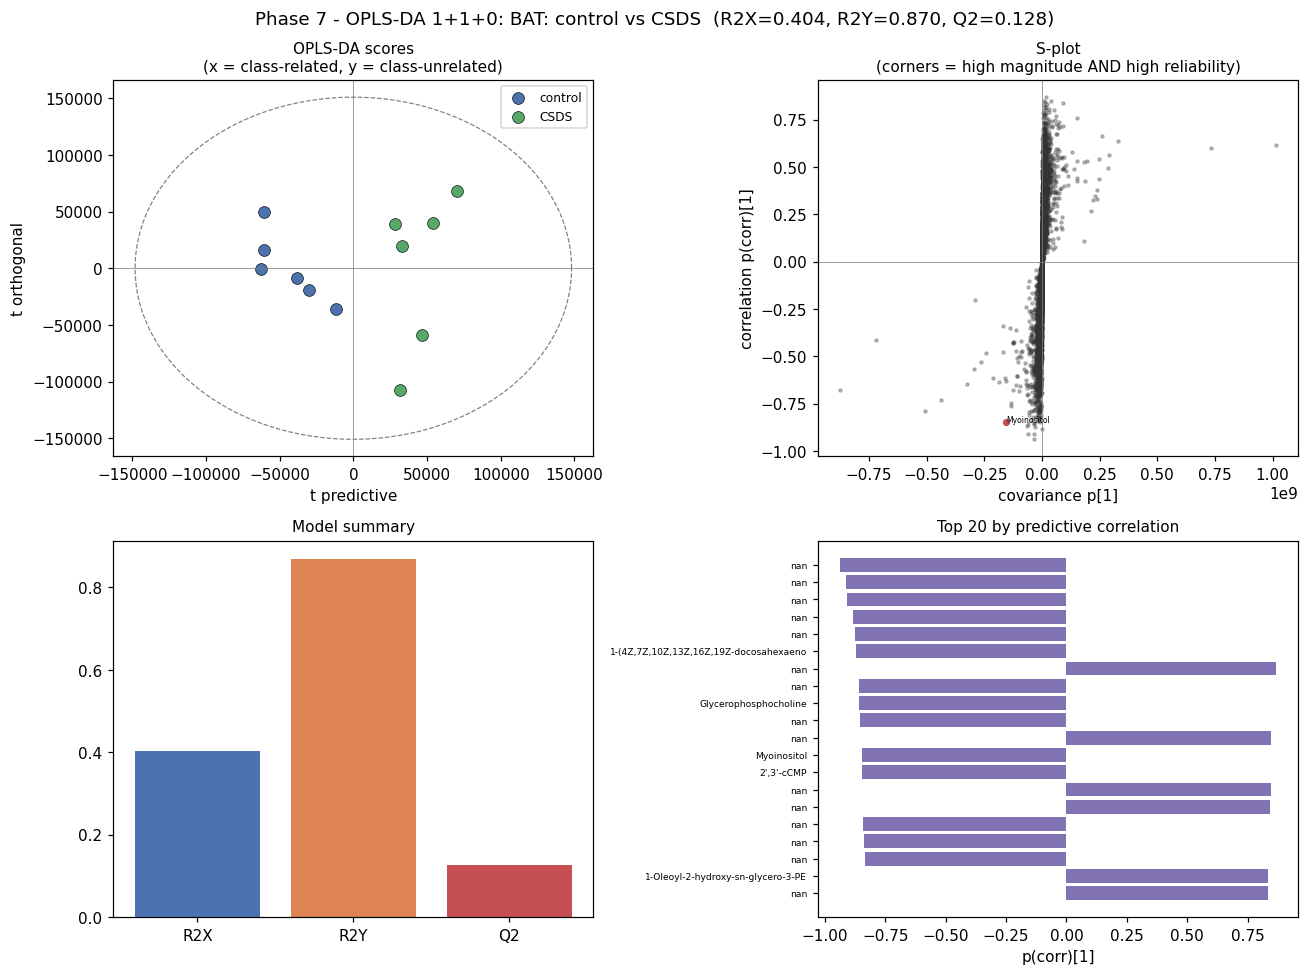

In [14]:
# =============================================================================
# PHASE 6 FIGURES
# =============================================================================

def phase6_figures(fitted, meta):
    m = meta.set_index("column")
    for key in ["all_pca", "all_noout_pca", "scw_pca", "bat_pca"]:
        f = fitted[key]
        pca, cols = f["model"], f["cols"]
        groups = m.loc[cols, "group"].values
        T, P = pca["T"], pca["P"]

        fig = plt.figure(figsize=(14, 9))
        ax = fig.add_subplot(2, 3, 1)
        for g in pd.unique(groups):
            sel = groups == g
            ax.scatter(T[sel, 0], T[sel, 1], s=50, label=g,
                       color=PALETTE.get(g, "#999"), edgecolor="k", lw=.4)
        # 95% Hotelling T2 ellipse
        _hotelling_ellipse(ax, T[:, 0], T[:, 1])
        ax.axhline(0, lw=.5, c="grey"); ax.axvline(0, lw=.5, c="grey")
        ax.set_xlabel(f"t[1] ({100*pca['R2X'][0]:.1f}%)")
        ax.set_ylabel(f"t[2] ({100*pca['R2X'][1]:.1f}%)")
        ax.legend(fontsize=7); ax.set_title("Score plot (t1 vs t2)", fontsize=9)

        ax = fig.add_subplot(2, 3, 2)
        ax.scatter(P[:, 0], P[:, 1], s=4, alpha=.3, color="#333")
        ax.axhline(0, lw=.5, c="grey"); ax.axvline(0, lw=.5, c="grey")
        ax.set_xlabel("p[1]"); ax.set_ylabel("p[2]")
        ax.set_title("Loading plot\n(features far from origin drive the scores)",
                     fontsize=9)

        ax = fig.add_subplot(2, 3, 3)
        ax.bar(np.arange(1, len(pca["R2X"]) + 1), pca["R2X"], color="#4C72B0",
               label="R2X per comp")
        ax.plot(np.arange(1, len(pca["R2X"]) + 1), pca["R2X_cum"], "o-",
                color="k", label="R2X cum")
        ax.plot(np.arange(1, len(f["q2_profile"]) + 1), f["q2_profile"], "s--",
                color="#C44E52", label="Q2 cum")
        ax.axhline(0, lw=.6, c="grey")
        ax.set_xlabel("component"); ax.legend(fontsize=7)
        ax.set_title("Scree / explained variance", fontsize=9)

        ax = fig.add_subplot(2, 3, 4)
        t2 = _hotelling_t2(T)
        lim = _t2_limit(T.shape[0], T.shape[1])
        ax.bar(range(len(t2)), t2, color=["#C44E52" if v > lim else "#4C72B0"
                                         for v in t2])
        ax.axhline(lim, ls="--", c="k", lw=.8)
        ax.set_xticks(range(len(t2)))
        ax.set_xticklabels(m.loc[cols, "sample"], rotation=90, fontsize=5)
        ax.set_ylabel("Hotelling T2")
        ax.set_title("Outlier screen (bars above line = 95% limit)", fontsize=9)

        ax = fig.add_subplot(2, 3, 5)
        from scipy.cluster.hierarchy import linkage, dendrogram
        Z = linkage(f["Xs"], method="ward")
        dendrogram(Z, labels=list(m.loc[cols, "sample"]), ax=ax,
                   leaf_font_size=5, color_threshold=0)
        ax.set_title("Hierarchical clustering (Ward)", fontsize=9)

        ax = fig.add_subplot(2, 3, 6)
        dmodx = np.sqrt((pca["residual"] ** 2).sum(axis=1) /
                        (pca["residual"].shape[1] - T.shape[1]))
        dmodx = dmodx / dmodx.mean()
        ax.bar(range(len(dmodx)), dmodx, color="#8172B3")
        ax.axhline(1.0, ls="--", c="grey", lw=.8)
        ax.set_xticks(range(len(dmodx)))
        ax.set_xticklabels(m.loc[cols, "sample"], rotation=90, fontsize=5)
        ax.set_ylabel("DModX (normalised)")
        ax.set_title("Distance to model (moderate outliers)", fontsize=9)

        fig.suptitle(f"Phase 6 - PCA-X: {f['label']}  "
                     f"(A={f['A']}, R2X={f['R2X']:.3f}, Q2={f['Q2']:.3f})",
                     fontsize=12)
        fig.tight_layout()
        fig.savefig(os.path.join(FIGDIR, f"04_pca_{key}.png"), dpi=200)
        plt.show()


def _hotelling_t2(T):
    s = T.std(axis=0, ddof=1)
    s = np.where(s == 0, 1, s)
    return ((T / s) ** 2).sum(axis=1)


def _t2_limit(n, a, alpha=0.05):
    if n - a <= 0:
        return np.inf
    return (a * (n - 1) / (n - a)) * stats.f.ppf(1 - alpha, a, n - a)


def _hotelling_ellipse(ax, x, y, alpha=0.05):
    n = len(x)
    if n <= 3:
        return
    f = stats.f.ppf(1 - alpha, 2, n - 2) * 2 * (n - 1) / (n - 2)
    th = np.linspace(0, 2 * np.pi, 200)
    ax.plot(np.sqrt(f) * x.std(ddof=1) * np.cos(th),
            np.sqrt(f) * y.std(ddof=1) * np.sin(th),
            ls="--", lw=.8, c="grey")


def phase7_figures(fitted, annot_names):
    for key, f in fitted.items():
        if f["kind"] == "PLS-DA":
            _fig_plsda(f, key, annot_names)
        elif f["kind"] == "OPLS-DA":
            _fig_oplsda(f, key, annot_names)


def _fig_plsda(f, key, names):
    pls, labels = f["model"], np.array(f["labels"])
    T = pls.T
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    ax = axes[0, 0]
    for g in pd.unique(labels):
        s = labels == g
        ax.scatter(T[s, 0], T[s, 1] if T.shape[1] > 1 else np.zeros(s.sum()),
                   s=55, label=g, color=PALETTE.get(g, "#999"),
                   edgecolor="k", lw=.4)
    _hotelling_ellipse(ax, T[:, 0], T[:, 1] if T.shape[1] > 1 else T[:, 0])
    ax.axhline(0, lw=.5, c="grey"); ax.axvline(0, lw=.5, c="grey")
    ax.set_xlabel(f"t[1] ({100*pls.R2X[0]:.1f}% of X)")
    ax.set_ylabel("t[2]" if T.shape[1] > 1 else "")
    ax.legend(fontsize=8); ax.set_title("Score plot", fontsize=10)

    ax = axes[0, 1]
    ax.scatter(pls.W[:, 0], pls.W[:, 1] if pls.W.shape[1] > 1 else
               np.zeros(pls.W.shape[0]), s=3, alpha=.25, c="#333")
    ax.axhline(0, lw=.5, c="grey"); ax.axvline(0, lw=.5, c="grey")
    ax.set_xlabel("w*c[1]"); ax.set_ylabel("w*c[2]")
    ax.set_title("Loading/weight plot", fontsize=10)

    ax = axes[1, 0]
    comps = np.arange(1, pls.A + 1)
    ax.bar(comps - .2, pls.R2X, width=.4, label="R2X", color="#4C72B0")
    ax.bar(comps + .2, pls.R2Y, width=.4, label="R2Y", color="#DD8452")
    ax.plot(comps, f["q2_profile"], "ks--", label="Q2 cum")
    ax.axhline(0, lw=.6, c="grey")
    ax.set_xticks(comps); ax.set_xlabel("component"); ax.legend(fontsize=8)
    ax.set_title("Fit vs predictive ability", fontsize=10)

    ax = axes[1, 1]
    vip = pls.vip()
    top = np.argsort(vip)[::-1][:20][::-1]
    ax.barh(range(len(top)), vip[top], color="#55A868")
    ax.axvline(1, ls="--", c="k", lw=.8)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([str(names[i])[:38] for i in top], fontsize=6)
    ax.set_xlabel("VIP")
    ax.set_title("Top 20 VIP (dashed line = 1)", fontsize=10)

    fig.suptitle(f"Phase 7 - PLS-DA: {f['label']}  "
                 f"(A={f['A']}, R2X={f['R2X']:.3f}, R2Y={f['R2Y']:.3f}, "
                 f"Q2={f['Q2']:.3f})", fontsize=12)
    fig.tight_layout()
    fig.savefig(os.path.join(FIGDIR, f"05_plsda_{key}.png"), dpi=200)
    plt.show()


def _fig_oplsda(f, key, names):
    opls, labels = f["model"], np.array(f["labels"])
    tp = opls.t_p.ravel()
    to = opls.T_o[0].ravel()
    cov, corr = opls.s_plot()

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    ax = axes[0, 0]
    for g in pd.unique(labels):
        s = labels == g
        ax.scatter(tp[s], to[s], s=60, label=g, color=PALETTE.get(g, "#999"),
                   edgecolor="k", lw=.4)
    _hotelling_ellipse(ax, tp, to)
    ax.axhline(0, lw=.5, c="grey"); ax.axvline(0, lw=.5, c="grey")
    ax.set_xlabel("t predictive"); ax.set_ylabel("t orthogonal")
    ax.legend(fontsize=8)
    ax.set_title("OPLS-DA scores\n(x = class-related, y = class-unrelated)",
                 fontsize=10)

    ax = axes[0, 1]
    ax.scatter(cov, corr, s=4, alpha=.3, c="#333")
    sig = (np.abs(corr) > .8) & (np.abs(cov) > np.percentile(np.abs(cov), 99))
    ax.scatter(cov[sig], corr[sig], s=14, c="#C44E52")
    for i in np.where(sig)[0][:12]:
        ax.annotate(str(names[i])[:24], (cov[i], corr[i]), fontsize=5)
    ax.axhline(0, lw=.5, c="grey"); ax.axvline(0, lw=.5, c="grey")
    ax.set_xlabel("covariance p[1]"); ax.set_ylabel("correlation p(corr)[1]")
    ax.set_title("S-plot\n(corners = high magnitude AND high reliability)",
                 fontsize=10)

    ax = axes[1, 0]
    ax.bar([0, 1, 2], [opls.R2X_cum, opls.R2Y_cum, f["Q2"]],
           color=["#4C72B0", "#DD8452", "#C44E52"])
    ax.set_xticks([0, 1, 2]); ax.set_xticklabels(["R2X", "R2Y", "Q2"])
    ax.axhline(0, lw=.6, c="grey")
    ax.set_title("Model summary", fontsize=10)

    ax = axes[1, 1]
    order = np.argsort(np.abs(corr))[::-1][:20][::-1]
    ax.barh(range(len(order)), corr[order], color="#8172B3")
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([str(names[i])[:38] for i in order], fontsize=6)
    ax.set_xlabel("p(corr)[1]")
    ax.set_title("Top 20 by predictive correlation", fontsize=10)

    fig.suptitle(f"Phase 7 - OPLS-DA 1+1+0: {f['label']}  "
                 f"(R2X={f['R2X']:.3f}, R2Y={f['R2Y']:.3f}, Q2={f['Q2']:.3f})",
                 fontsize=12)
    fig.tight_layout()
    fig.savefig(os.path.join(FIGDIR, f"06_oplsda_{key}.png"), dpi=200)
    plt.show()


phase6_figures(fitted, meta)
phase7_figures(fitted, raw["Metabolite"].astype(str).values)


---
## 9. Phase 8 — Model validation

Three independent checks, because R²Y on 12 samples and 5,795 features is not
evidence of anything:

1. **Repeated stratified k-fold** — accuracy, balanced accuracy, precision,
   recall, F1, ROC AUC as mean ± SD across folds. `k` defaults to the smallest
   class size (capped at 6) so every fold retains both classes; 20 repeats
   because a single split at this n is pure noise.
2. **Permutation test** — labels shuffled, the *entire* model refitted each
   time. Acceptance (Eriksson et al.): observed Q² beyond the permuted null,
   and a low/negative intercept on the validation plot.
3. **CV-ANOVA** — F-test on the cross-validated residuals.


PHASE 8 -- MODEL VALIDATION
With K = 5795 features and n = 11-18 samples, a supervised model can
separate ANY random labelling perfectly. R2Y alone is therefore
uninformative -- only out-of-sample evidence counts. Three independent
checks are run:
  1. Repeated stratified k-fold classification metrics
  2. Permutation test (1000 label shuffles, full refit each time)
  3. CV-ANOVA F-test on the cross-validated residuals

--- scW (PLS-DA, A=3, n=18)
  stratified 6-fold x 20 repeats:
    accuracy             0.692 +/- 0.253
    balanced_accuracy    0.692 +/- 0.253
    f1                   0.613 +/- 0.294
    precision            0.576 +/- 0.313
    recall               0.692 +/- 0.253
  permutation (1000): p(R2Y)=0.0070  p(Q2)=0.0010  Q2 intercept=-0.535
  CV-ANOVA: F=2.790  p=0.07925  (df 3, 14)
  VERDICT: BORDERLINE - suggestive, needs an independent cohort


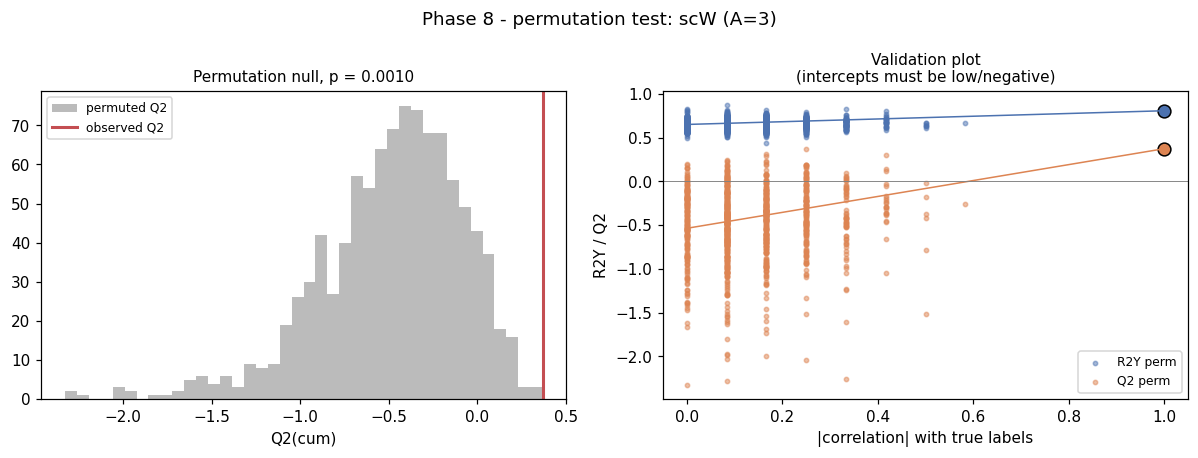


--- scW: control vs CMVS (PLS-DA, A=2, n=12)
  stratified 6-fold x 20 repeats:
    accuracy             0.833 +/- 0.262
    balanced_accuracy    0.833 +/- 0.262
    f1                   0.786 +/- 0.326
    precision            0.762 +/- 0.359
    recall               0.833 +/- 0.262
    roc_auc              0.933 +/- 0.250
  permutation (1000): p(R2Y)=0.0100  p(Q2)=0.0110  Q2 intercept=-0.369
  CV-ANOVA: F=8.020  p=0.01001  (df 2, 9)
  VERDICT: RELIABLE - separation survives out-of-sample testing


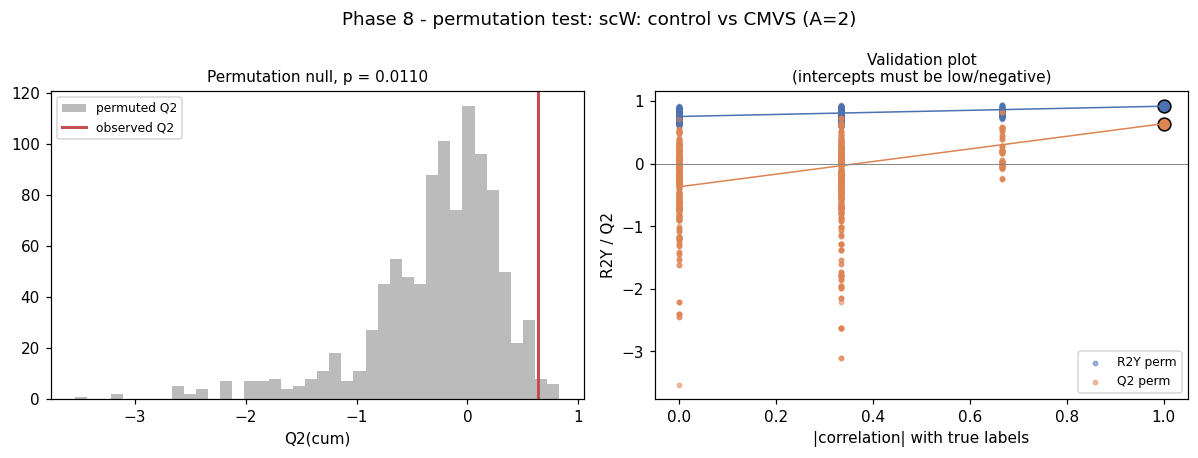


--- scW: control vs CSDS (PLS-DA, A=3, n=12)
  stratified 6-fold x 20 repeats:
    accuracy             0.833 +/- 0.262
    balanced_accuracy    0.833 +/- 0.262
    f1                   0.786 +/- 0.326
    precision            0.762 +/- 0.359
    recall               0.833 +/- 0.262
    roc_auc              0.942 +/- 0.235
  permutation (1000): p(R2Y)=0.0549  p(Q2)=0.0100  Q2 intercept=-0.081
  CV-ANOVA: F=10.778  p=0.003493  (df 3, 8)
  VERDICT: RELIABLE - separation survives out-of-sample testing


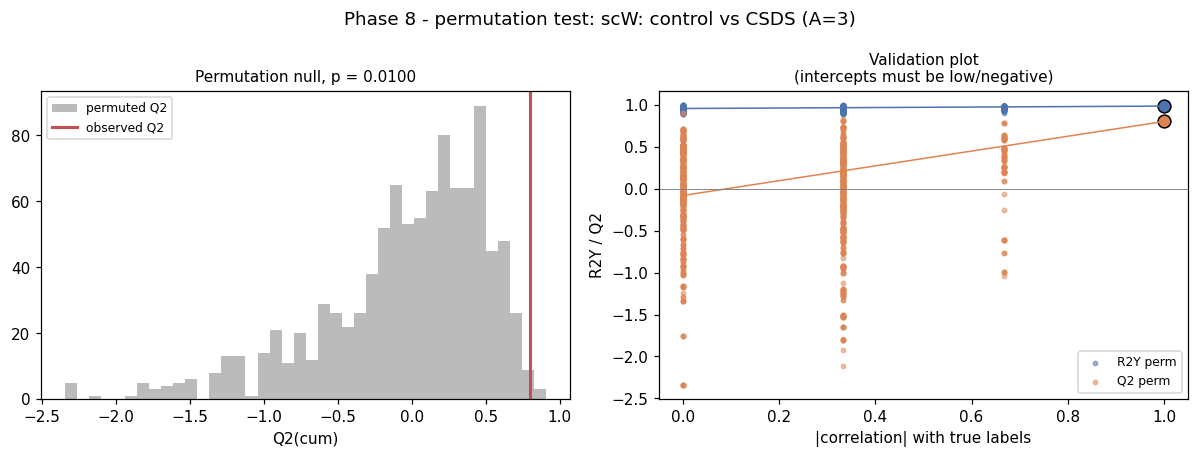


--- BAT (PLS-DA, A=2, n=17)
  stratified 5-fold x 20 repeats:
    accuracy             0.539 +/- 0.205
    balanced_accuracy    0.538 +/- 0.208
    f1                   0.452 +/- 0.213
    precision            0.414 +/- 0.224
    recall               0.538 +/- 0.208
  permutation (1000): p(R2Y)=0.0639  p(Q2)=0.0589  Q2 intercept=-0.478
  CV-ANOVA: F=0.372  p=0.6962  (df 2, 14)
  VERDICT: NOT SUPPORTED - fit is consistent with overfitting


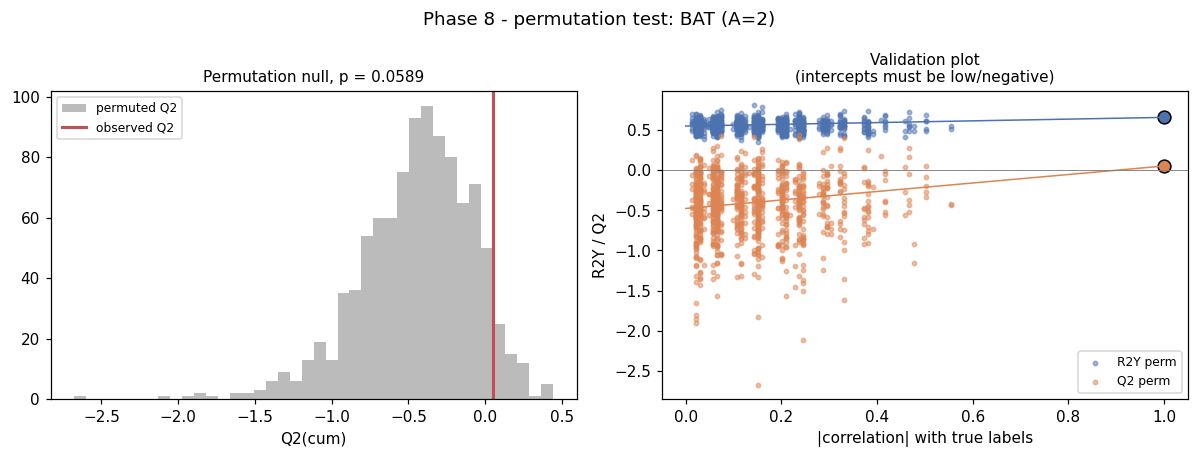


--- BAT: control vs CMVS (PLS-DA, A=2, n=11)
  stratified 5-fold x 20 repeats:
    accuracy             0.985 +/- 0.086
    balanced_accuracy    0.985 +/- 0.086
    f1                   0.980 +/- 0.114
    precision            0.978 +/- 0.129
    recall               0.985 +/- 0.086
    roc_auc              1.000 +/- 0.000
  permutation (1000): p(R2Y)=0.0080  p(Q2)=0.0200  Q2 intercept=-0.483
  CV-ANOVA: F=6.285  p=0.02288  (df 2, 8)
  VERDICT: RELIABLE - separation survives out-of-sample testing


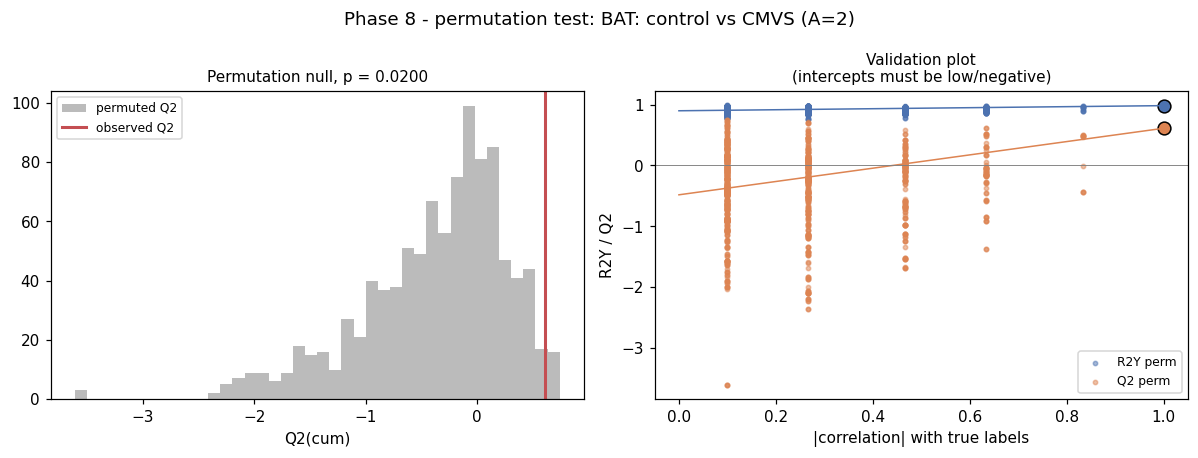


--- BAT: control vs CSDS (PLS-DA, A=2, n=12)
  stratified 6-fold x 20 repeats:
    accuracy             0.729 +/- 0.303
    balanced_accuracy    0.729 +/- 0.303
    f1                   0.658 +/- 0.363
    precision            0.623 +/- 0.396
    recall               0.729 +/- 0.303
    roc_auc              0.833 +/- 0.374
  permutation (1000): p(R2Y)=0.4456  p(Q2)=0.1319  Q2 intercept=-0.429
  CV-ANOVA: F=1.050  p=0.3892  (df 2, 9)
  VERDICT: NOT SUPPORTED - fit is consistent with overfitting


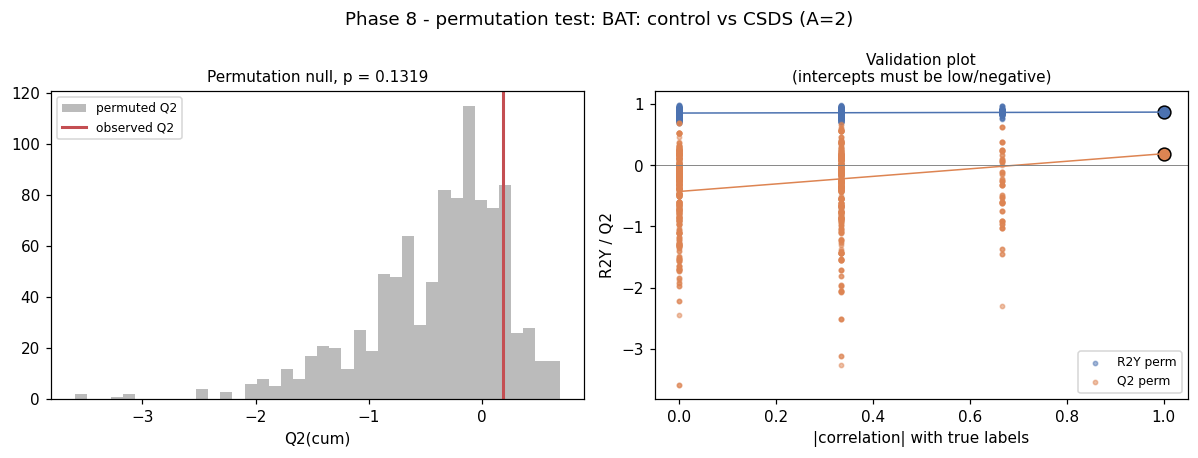

In [15]:
# =============================================================================
# PHASE 8 -- VALIDATION
# =============================================================================

def phase8_validation(fitted, n_perm=N_PERM):
    head("PHASE 8 -- MODEL VALIDATION")
    log(textwrap.dedent(f"""
    With K = 5795 features and n = 11-18 samples, a supervised model can
    separate ANY random labelling perfectly. R2Y alone is therefore
    uninformative -- only out-of-sample evidence counts. Three independent
    checks are run:
      1. Repeated stratified k-fold classification metrics
      2. Permutation test ({n_perm} label shuffles, full refit each time)
      3. CV-ANOVA F-test on the cross-validated residuals
    """).strip())

    results = {}
    for key, f in fitted.items():
        if f["kind"] != "PLS-DA":
            continue
        log(f"\n--- {f['label']} ({f['kind']}, A={f['A']}, n={f['n']})")
        M, labels, A = f["M"], f["labels"], f["A"]

        metrics, k = stratified_cv_metrics(M, labels, A, SCALING)
        log(f"  stratified {k}-fold x 20 repeats:")
        for name, (mu, sd) in metrics.items():
            log(f"    {name:20s} {mu:.3f} +/- {sd:.3f}")

        perm = permutation_test(M, labels, A, n_perm, SCALING, CV_GROUPS)
        log(f"  permutation ({n_perm}): p(R2Y)={perm['p_R2Y']:.4f}  "
            f"p(Q2)={perm['p_Q2']:.4f}  "
            f"Q2 intercept={perm['intercept_Q2']:+.3f}")

        anova = cv_anova(M, labels, A, SCALING, CV_GROUPS)
        log(f"  CV-ANOVA: F={anova['F']:.3f}  p={anova['p']:.4g}  "
            f"(df {anova['df_reg']}, {anova['df_res']})")

        verdict = _verdict(perm, anova, f["Q2"])
        log(f"  VERDICT: {verdict}")
        results[key] = {"metrics": metrics, "k": k, "perm": perm,
                        "anova": anova, "verdict": verdict}
        _fig_permutation(perm, f, key)
    return results


def _verdict(perm, anova, q2):
    ok = []
    ok.append(q2 > 0.4)
    ok.append(perm["p_Q2"] < 0.05)
    ok.append(perm["intercept_Q2"] < 0.05)
    ok.append(anova["p"] < 0.05 if np.isfinite(anova["p"]) else False)
    n = sum(ok)
    if n >= 3:
        return "RELIABLE - separation survives out-of-sample testing"
    if n == 2:
        return "BORDERLINE - suggestive, needs an independent cohort"
    return "NOT SUPPORTED - fit is consistent with overfitting"


def _fig_permutation(perm, f, key):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    ax = axes[0]
    ax.hist(perm["perm_Q2"], bins=40, color="#BBB", label="permuted Q2")
    ax.axvline(perm["real_Q2"], c="#C44E52", lw=2, label="observed Q2")
    ax.set_xlabel("Q2(cum)"); ax.legend(fontsize=8)
    ax.set_title(f"Permutation null, p = {perm['p_Q2']:.4f}", fontsize=10)

    ax = axes[1]
    ax.scatter(perm["perm_corr"], perm["perm_R2Y"], s=8, c="#4C72B0",
               alpha=.5, label="R2Y perm")
    ax.scatter(perm["perm_corr"], perm["perm_Q2"], s=8, c="#DD8452",
               alpha=.5, label="Q2 perm")
    ax.scatter([1], [perm["real_R2Y"]], s=70, c="#4C72B0", edgecolor="k")
    ax.scatter([1], [perm["real_Q2"]], s=70, c="#DD8452", edgecolor="k")
    for y0, c in [(perm["intercept_R2Y"], "#4C72B0"),
                  (perm["intercept_Q2"], "#DD8452")]:
        ax.plot([0, 1], [y0, perm["real_R2Y"] if c == "#4C72B0"
                         else perm["real_Q2"]], c=c, lw=1)
    ax.axhline(0, lw=.6, c="grey")
    ax.set_xlabel("|correlation| with true labels"); ax.set_ylabel("R2Y / Q2")
    ax.legend(fontsize=8)
    ax.set_title("Validation plot\n(intercepts must be low/negative)",
                 fontsize=10)
    fig.suptitle(f"Phase 8 - permutation test: {f['label']} (A={f['A']})")
    fig.tight_layout()
    fig.savefig(os.path.join(FIGDIR, f"07_permutation_{key}.png"), dpi=200)
    plt.show()


val_results = phase8_validation(fitted)


---
## 10. Phase 9 — Biomarker discovery

Univariate statistics (fold change, Welch t-test, BH-FDR, 95% CI) are combined
with the multivariate VIP, so a metabolite must be both *individually*
different and *important to the class model*.

This cell also runs the **independent VIP cross-check** against the workbook's
own SIMCA-computed VIP columns — the strongest available test that the whole
preprocessing and PLS chain is correct.


PHASE 9 -- BIOMARKER DISCOVERY
Univariate statistics (fold change, t-test, BH-FDR) are combined with the multivariate VIP so that a metabolite must be both individually different AND important to the class model.

scW: control vs CMVS     VIP>1:   518   FDR<0.05:     6   both:     3   -> biomarkers_scw_ctrl_cmvs.csv
   VIP cross-check vs workbook column: Spearman rho = 1.0000, max 26.268 vs 26.268, n(VIP>1) 518 vs 518
                 Metabolite    log2FC  p_value    FDR_q       VIP
                L-Carnitine  0.962119 0.000870 0.121824 26.267966
        α-Hydroxymetoprolol  0.889517 0.025756 0.196905 18.062129
                   Creatine  0.134630 0.727643 0.819890 13.706989
                    Choline -0.156643 0.599076 0.726285 13.070391
                  Adenosine  1.191053 0.000813 0.121824 12.326743
              Palmitic acid  0.507579 0.570432 0.706487 10.680063
                    Betaine  0.423028 0.091506 0.282416 10.353354
                    Taurine  0.652760 0.010148 0.

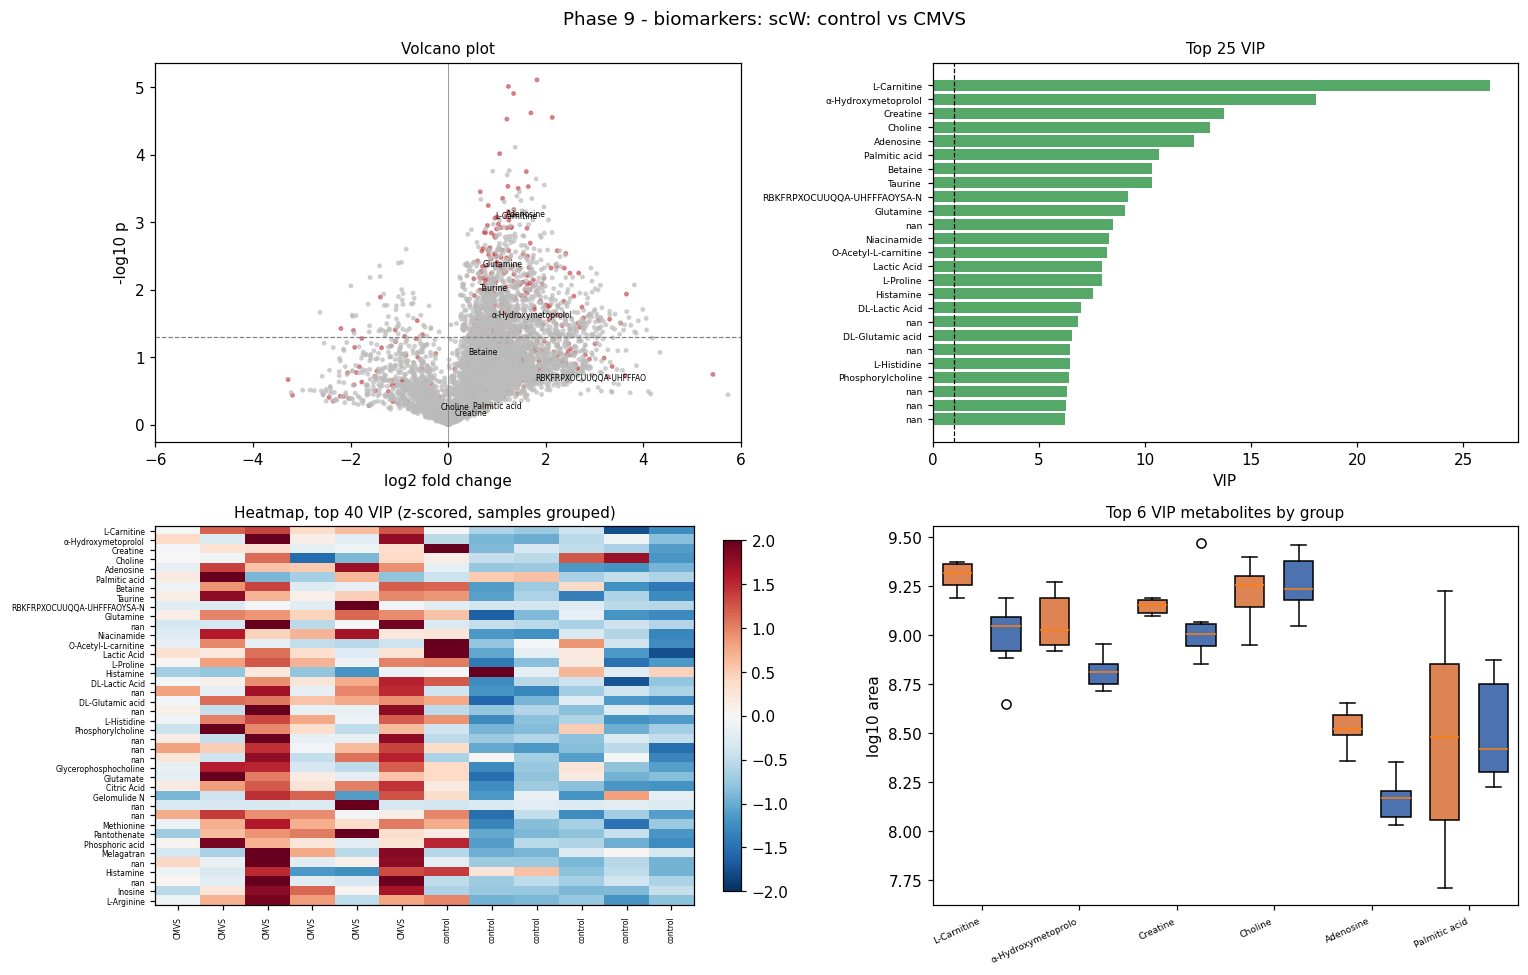

scW: control vs CSDS     VIP>1:   484   FDR<0.05:     0   both:     0   -> biomarkers_scw_ctrl_csds.csv
   VIP cross-check vs workbook column: Spearman rho = 1.0000, max 22.264 vs 22.264, n(VIP>1) 479 vs 479
          Metabolite    log2FC  p_value    FDR_q       VIP
             Choline -0.649407 0.081198 0.383761 22.621286
         L-Carnitine  0.601869 0.042236 0.318032 21.783952
            Creatine  0.074532 0.850826 0.920735 18.601840
             Betaine  0.572518 0.029534 0.293638 14.643151
O-Acetyl-L-carnitine -0.011529 0.975947 0.988398 11.480882
           Glutamine  0.733614 0.004124 0.198606 11.428858
       Palmitic acid  0.527820 0.338872 0.607491 10.777301
             Taurine  0.506858 0.034035 0.301721 10.560524
         Niacinamide  0.677190 0.005706 0.204117  9.955108
           L-Proline  0.707088 0.041094 0.313521  9.473097



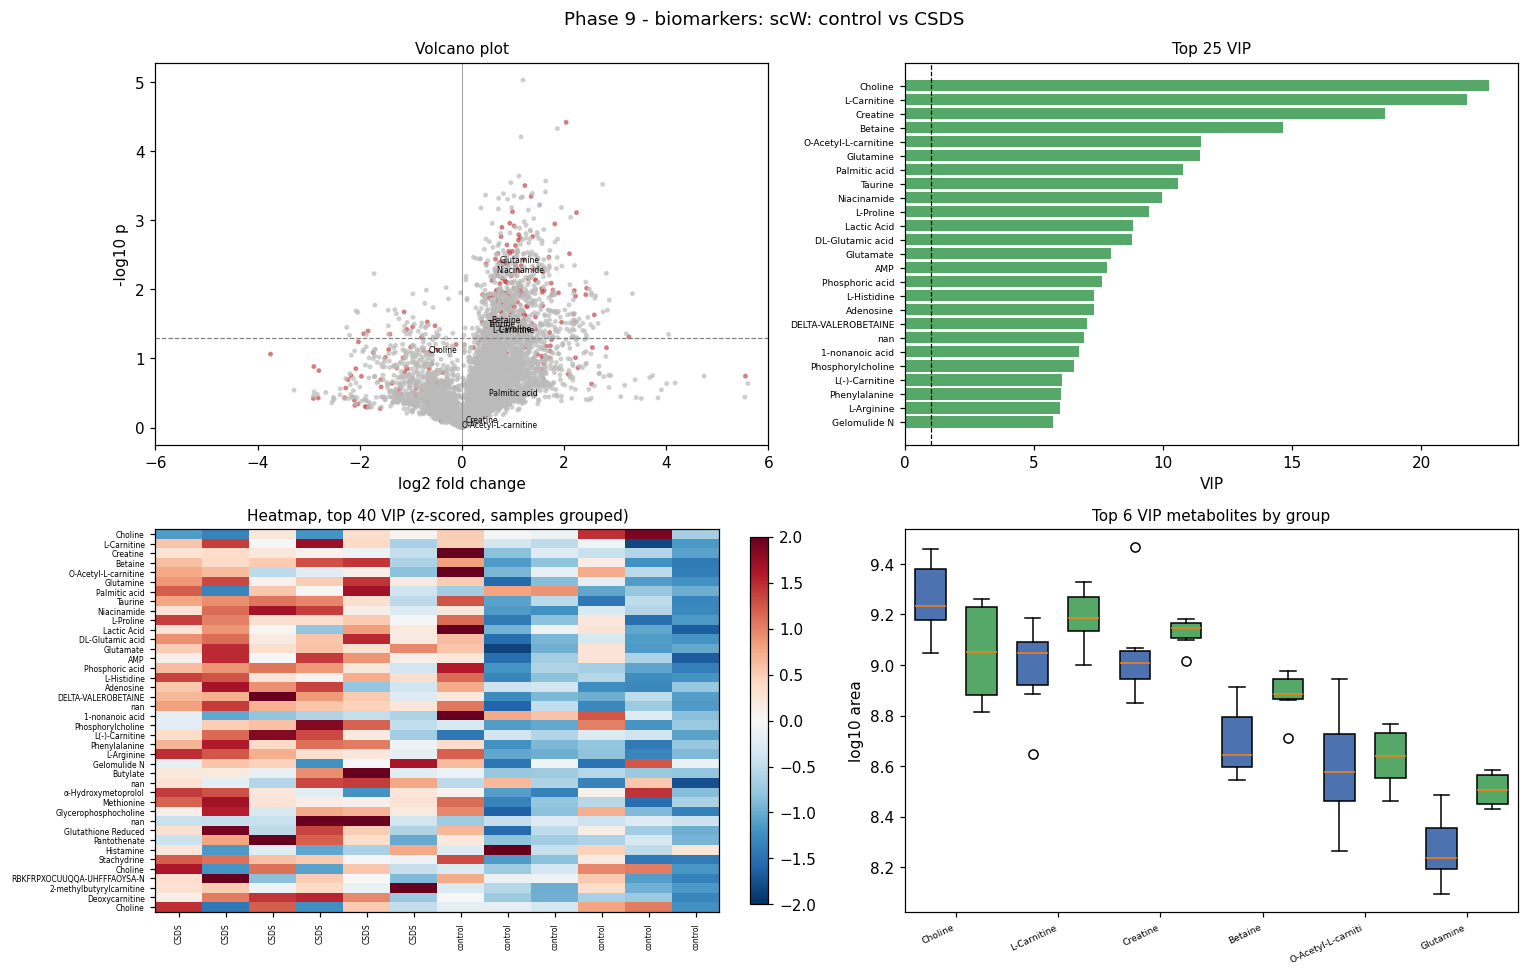

BAT: control vs CMVS     VIP>1:   405   FDR<0.05:     5   both:     1   -> biomarkers_bat_ctrl_cmvs.csv
   VIP cross-check vs workbook column: Spearman rho = 1.0000, max 28.483 vs 28.483, n(VIP>1) 405 vs 405
                   Metabolite    log2FC  p_value    FDR_q       VIP
  RBKFRPXOCUUQQA-UHFFFAOYSA-N -1.443038 0.070893 0.706364 28.483185
                      Betaine  0.507647 0.000960 0.290010 25.780329
                     Creatine -0.244663 0.199953 0.706364 15.292144
                  L-Carnitine -0.144319 0.423134 0.744758 14.886351
          DELTA-VALEROBETAINE  0.581363 0.040083 0.702254 14.490605
        Glycerophosphocholine -0.670733 0.006607 0.480545 13.766614
(R)-3-hydroxybutyrylcarnitine -2.185069 0.019148 0.630485 12.519897
               DL-Lactic Acid  0.701735 0.079348 0.706364 11.494254
                      Taurine  0.293680 0.059562 0.706364 10.960604
                  Niacinamide  0.257568 0.003911 0.371173 10.348345



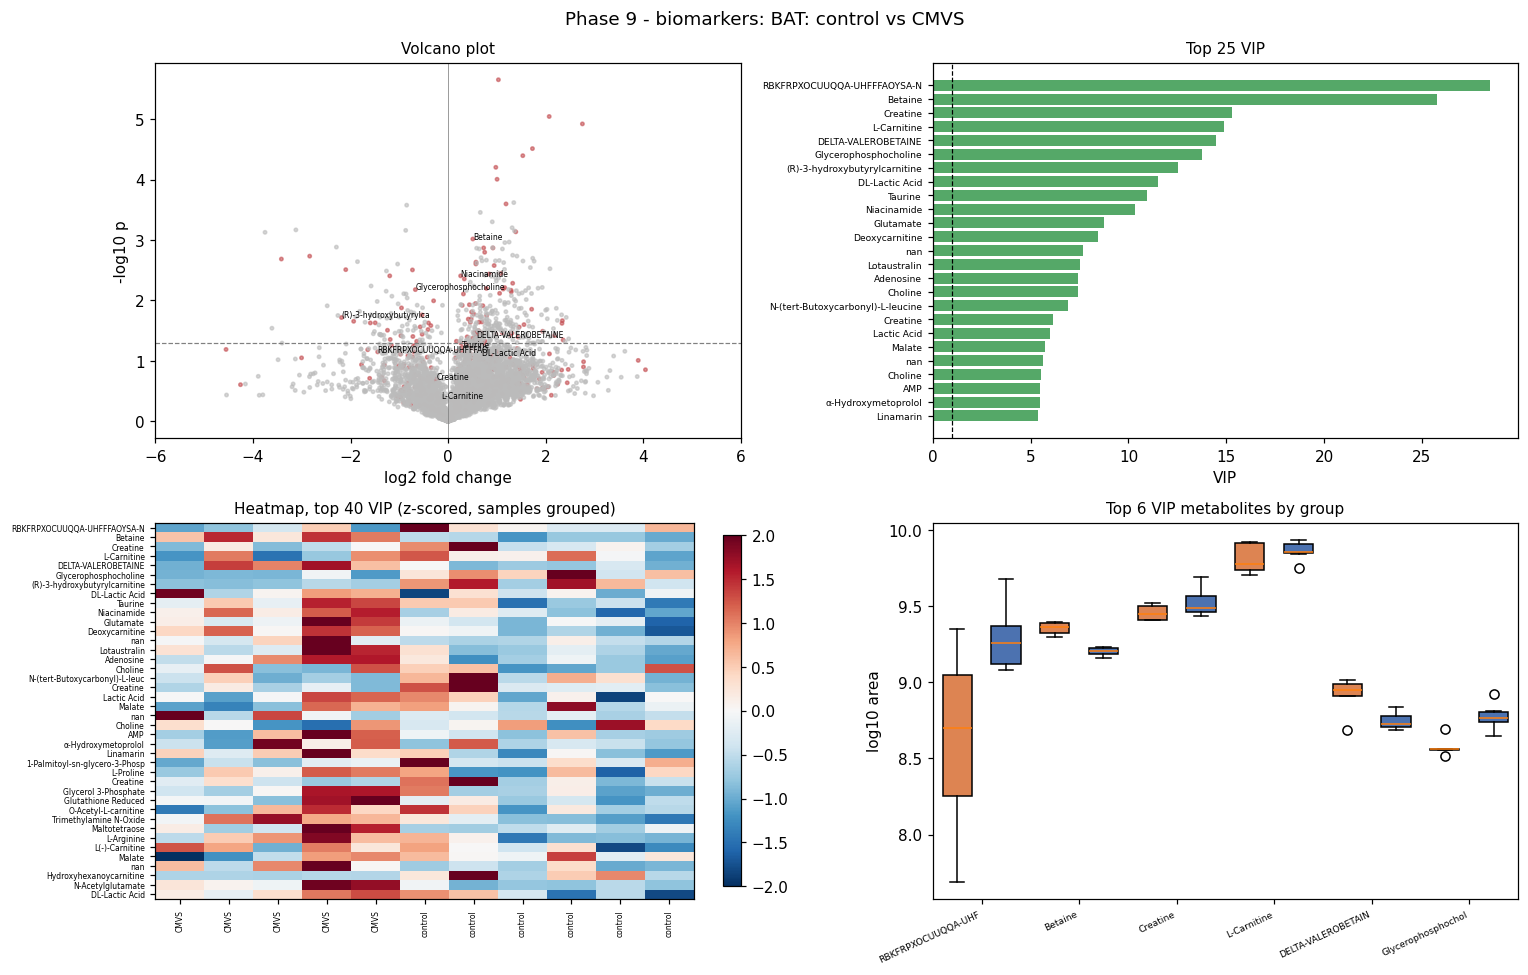

BAT: control vs CSDS     VIP>1:   400   FDR<0.05:     0   both:     0   -> biomarkers_bat_ctrl_csds.csv
   VIP cross-check vs workbook column: Spearman rho = 1.0000, max 24.250 vs 24.250, n(VIP>1) 400 vs 400
                   Metabolite    log2FC  p_value    FDR_q       VIP
                      Choline  0.775277 0.117415 0.818614 24.250109
                      Betaine  0.525697 0.060688 0.785537 22.572420
                     Creatine -0.322440 0.104725 0.813560 20.361351
  RBKFRPXOCUUQQA-UHFFFAOYSA-N -0.612649 0.305555 0.884668 19.095516
        Glycerophosphocholine -0.727434 0.005871 0.539673 15.764368
                  L-Carnitine  0.104967 0.445082 0.899948 15.595981
(R)-3-hydroxybutyrylcarnitine -1.706922 0.029399 0.744021 12.926128
                 Lotaustralin  1.349482 0.034908 0.744021 10.263105
          DELTA-VALEROBETAINE  0.311862 0.103278 0.813560  9.059051
               Deoxycarnitine  0.744132 0.092431 0.813560  8.844780



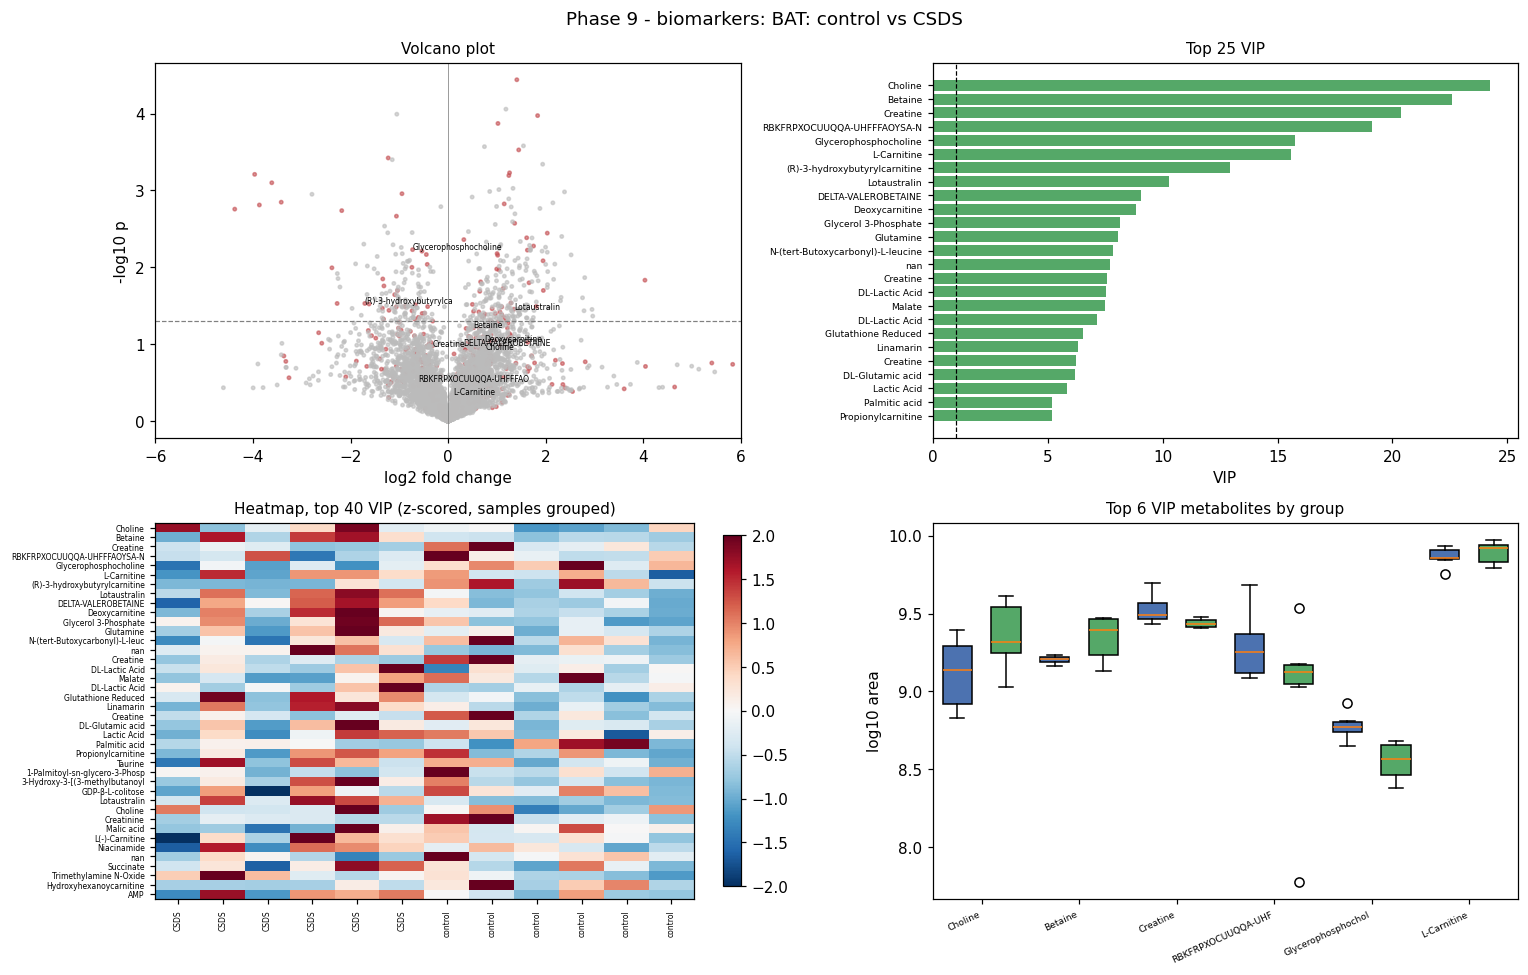

In [16]:
# =============================================================================
# PHASE 9 -- BIOMARKER DISCOVERY
# =============================================================================

def phase9_biomarkers(fitted, X, meta, raw):
    head("PHASE 9 -- BIOMARKER DISCOVERY")
    log("Univariate statistics (fold change, t-test, BH-FDR) are combined "
        "with the multivariate VIP so that a metabolite must be both "
        "individually different AND important to the class model.\n")

    names = raw["Metabolite"].astype(str).values
    kegg = raw["KEGG ID"].astype(str).values
    mz = raw["m/z"].values
    rt = raw["RT [min]"].values
    conf = raw["Confidence in annotation"].astype(str).values

    # Independent check: the workbook already carries VIP columns computed in
    # SIMCA. Reproducing them is a hard test of the whole preprocessing +
    # PLS chain that does not depend on the R2/Q2 summary table.
    REF_VIP = {
        "scw_ctrl_cmvs": "VIP score: (scW_CMVS) vs (scW_control)",
        "scw_ctrl_csds": "VIP score: (scW_CSDS) vs (scW_control)",
        "bat_ctrl_cmvs": "VIP score: (BAT_CMVS) vs (BAT_control)",
        "bat_ctrl_csds": "VIP score: (BAT_CSDS) vs (BAT_control)",
    }

    tables = {}
    for key in ["scw_ctrl_cmvs", "scw_ctrl_csds",
                "bat_ctrl_cmvs", "bat_ctrl_csds"]:
        f = fitted[key]
        labels = np.array(f["labels"])
        M = f["M"]
        ctrl = M[labels == "control"]
        case = M[labels != "control"]
        case_name = [g for g in pd.unique(labels) if g != "control"][0]

        with np.errstate(divide="ignore", invalid="ignore"):
            fc = case.mean(axis=0) / ctrl.mean(axis=0)
            log2fc = np.log2(fc)
        t, p = stats.ttest_ind(case, ctrl, axis=0, equal_var=False)
        q = benjamini_hochberg(np.nan_to_num(p, nan=1.0))
        vip = f["model"].vip()

        # 95% CI on the difference of means (Welch)
        se = np.sqrt(case.var(axis=0, ddof=1) / case.shape[0] +
                     ctrl.var(axis=0, ddof=1) / ctrl.shape[0])
        dfree = (se ** 4) / (
            (case.var(axis=0, ddof=1) / case.shape[0]) ** 2 / (case.shape[0] - 1) +
            (ctrl.var(axis=0, ddof=1) / ctrl.shape[0]) ** 2 / (ctrl.shape[0] - 1))
        tcrit = stats.t.ppf(0.975, np.nan_to_num(dfree, nan=1))
        diff = case.mean(axis=0) - ctrl.mean(axis=0)

        tab = pd.DataFrame({
            "Metabolite": names, "KEGG": kegg, "m/z": mz, "RT_min": rt,
            "Annotation_confidence": conf,
            "mean_control": ctrl.mean(axis=0), "sd_control": ctrl.std(axis=0, ddof=1),
            f"mean_{case_name}": case.mean(axis=0),
            f"sd_{case_name}": case.std(axis=0, ddof=1),
            "fold_change": fc, "log2FC": log2fc,
            "diff": diff, "CI95_low": diff - tcrit * se,
            "CI95_high": diff + tcrit * se,
            "p_value": p, "FDR_q": q, "VIP": vip,
            "feature_index": np.arange(len(names)),
        })
        tab["significant"] = (tab["FDR_q"] < 0.05) | (tab["VIP"] > 1)
        tab = tab.sort_values("VIP", ascending=False).reset_index(drop=True)
        tables[key] = tab

        out = os.path.join(TABDIR, f"biomarkers_{key}.csv")
        tab.to_csv(out, index=False)
        n_vip = int((tab["VIP"] > 1).sum())
        n_fdr = int((tab["FDR_q"] < 0.05).sum())
        n_both = int(((tab["VIP"] > 1) & (tab["FDR_q"] < 0.05)).sum())
        log(f"{f['label']:24s} VIP>1: {n_vip:5d}   FDR<0.05: {n_fdr:5d}   "
            f"both: {n_both:5d}   -> {os.path.basename(out)}")

        ref_col = REF_VIP.get(key)
        if ref_col in raw.columns:
            ref = pd.to_numeric(raw[ref_col], errors="coerce").values
            ours = vip
            # the workbook's VIP columns were all computed on 2-component
            # pairwise models, even where the summary table lists A=3
            if f["A"] != 2:
                Xs2, _, _ = scale_matrix(M, SCALING)
                Ys2, _ = dummy_y(labels)
                ours = PLSDA(2).fit(Xs2, Ys2).vip()
            ok = ~np.isnan(ref)
            rho = pd.Series(ours[ok]).corr(pd.Series(ref[ok]), method="spearman")
            log(f"   VIP cross-check vs workbook column: Spearman rho = "
                f"{rho:.4f}, max {ours.max():.3f} vs {np.nanmax(ref):.3f}, "
                f"n(VIP>1) {int((ours>1).sum())} vs {int((ref[ok]>1).sum())}")
        log(tab.head(10)[["Metabolite", "log2FC", "p_value", "FDR_q", "VIP"]]
            .to_string(index=False))
        log("")

        _fig_biomarkers(tab, f, key, M, labels)
    return tables


def _fig_biomarkers(tab, f, key, M, labels):
    fig = plt.figure(figsize=(14, 9))

    ax = fig.add_subplot(2, 2, 1)
    lp = -np.log10(np.clip(tab["p_value"].values, 1e-300, None))
    sig = tab["significant"].values
    ax.scatter(tab["log2FC"], lp, s=5, c=np.where(sig, "#C44E52", "#BBB"),
               alpha=.6)
    ax.axhline(-np.log10(0.05), ls="--", c="grey", lw=.8)
    ax.axvline(0, lw=.5, c="grey")
    for _, r in tab.head(10).iterrows():
        ax.annotate(str(r["Metabolite"])[:22],
                    (r["log2FC"], -np.log10(max(r["p_value"], 1e-300))),
                    fontsize=5)
    ax.set_xlabel("log2 fold change"); ax.set_ylabel("-log10 p")
    ax.set_xlim(-6, 6)
    ax.set_title("Volcano plot", fontsize=10)

    ax = fig.add_subplot(2, 2, 2)
    top = tab.head(25).iloc[::-1]
    ax.barh(range(len(top)), top["VIP"], color="#55A868")
    ax.axvline(1, ls="--", c="k", lw=.8)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([str(s)[:36] for s in top["Metabolite"]], fontsize=6)
    ax.set_xlabel("VIP"); ax.set_title("Top 25 VIP", fontsize=10)

    ax = fig.add_subplot(2, 2, 3)
    pos40 = tab["feature_index"].values[:40]
    heat = np.column_stack([_zscore(M[:, i]) for i in pos40])   # n x 40
    order_s = np.argsort(labels)
    im = ax.imshow(heat[order_s].T, aspect="auto", cmap="RdBu_r",
                   vmin=-2, vmax=2)
    ax.set_yticks(range(len(pos40)))
    ax.set_yticklabels([str(s)[:30] for s in tab["Metabolite"].values[:40]],
                       fontsize=5)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(np.array(labels)[order_s], rotation=90, fontsize=5)
    plt.colorbar(im, ax=ax, fraction=.03)
    ax.set_title("Heatmap, top 40 VIP (z-scored, samples grouped)", fontsize=10)

    ax = fig.add_subplot(2, 2, 4)
    groups_u = list(pd.unique(labels))
    pos6 = tab["feature_index"].values[:6]
    data, ticks, facecols = [], [], []
    for j, i in enumerate(pos6):
        for g in groups_u:
            data.append(np.log10(M[np.array(labels) == g, i] + 1))
            facecols.append(PALETTE.get(g, "#999"))
        ticks.append(str(tab["Metabolite"].values[j])[:18])
    bp = ax.boxplot(data, patch_artist=True, widths=.6)
    for patch, col in zip(bp["boxes"], facecols):
        patch.set_facecolor(col)
    ngrp = len(groups_u)
    ax.set_xticks(np.arange(1, len(data) + 1, ngrp) + (ngrp - 1) / 2)
    ax.set_xticklabels(ticks, rotation=25, fontsize=6, ha="right")
    ax.set_ylabel("log10 area")
    ax.set_title("Top 6 VIP metabolites by group", fontsize=10)

    fig.suptitle(f"Phase 9 - biomarkers: {f['label']}", fontsize=12)
    fig.tight_layout()
    fig.savefig(os.path.join(FIGDIR, f"08_biomarkers_{key}.png"), dpi=200)
    plt.show()


def _zscore(v):
    s = v.std(ddof=1)
    return (v - v.mean()) / (s if s else 1)


biomarker_tables = phase9_biomarkers(fitted, X_clean, meta, raw)


### 10.1 Top biomarkers by contrast

Full ranked tables are written to `tables/biomarkers_*.csv`.

In [17]:
for key, tab in biomarker_tables.items():
    print(f"\n=== {fitted[key]['label']} ===")
    cols = ["Metabolite", "log2FC", "p_value", "FDR_q", "VIP",
            "Annotation_confidence"]
    display(tab.head(15)[cols].round(4))



=== scW: control vs CMVS ===


,Metabolite,log2FC,p_value,FDR_q,VIP,Annotation_confidence
0,L-Carnitine,0.9621,0.0009,0.1218,26.2680,High
1,α-Hydroxymetoprolol,0.8895,0.0258,0.1969,18.0621,Low
2,Creatine,0.1346,0.7276,0.8199,13.7070,High
3,Choline,-0.1566,0.5991,0.7263,13.0704,Low
4,Adenosine,1.1911,0.0008,0.1218,12.3267,High
5,Palmitic acid,0.5076,0.5704,0.7065,10.6801,Low
6,Betaine,0.4230,0.0915,0.2824,10.3534,High
7,Taurine,0.6528,0.0101,0.1613,10.3143,High
8,RBKFRPXOCUUQQA-UHFFFAOYSA-N,1.7928,0.2200,0.4037,9.2098,Low
9,Glutamine,0.7068,0.0045,0.1408,9.0756,High



=== scW: control vs CSDS ===


,Metabolite,log2FC,p_value,FDR_q,VIP,Annotation_confidence
0,Choline,-0.6494,0.0812,0.3838,22.6213,Low
1,L-Carnitine,0.6019,0.0422,0.3180,21.7840,High
2,Creatine,0.0745,0.8508,0.9207,18.6018,High
3,Betaine,0.5725,0.0295,0.2936,14.6432,High
4,O-Acetyl-L-carnitine,-0.0115,0.9759,0.9884,11.4809,High
5,Glutamine,0.7336,0.0041,0.1986,11.4289,High
6,Palmitic acid,0.5278,0.3389,0.6075,10.7773,Low
7,Taurine,0.5069,0.0340,0.3017,10.5605,High
8,Niacinamide,0.6772,0.0057,0.2041,9.9551,High
9,L-Proline,0.7071,0.0411,0.3135,9.4731,High



=== BAT: control vs CMVS ===


,Metabolite,log2FC,p_value,FDR_q,VIP,Annotation_confidence
0,RBKFRPXOCUUQQA-UHFFFAOYSA-N,-1.4430,0.0709,0.7064,28.4832,Low
1,Betaine,0.5076,0.0010,0.2900,25.7803,High
2,Creatine,-0.2447,0.2000,0.7064,15.2921,High
3,L-Carnitine,-0.1443,0.4231,0.7448,14.8864,High
4,DELTA-VALEROBETAINE,0.5814,0.0401,0.7023,14.4906,Medium
5,Glycerophosphocholine,-0.6707,0.0066,0.4805,13.7666,Medium
6,(R)-3-hydroxybutyrylcarnitine,-2.1851,0.0191,0.6305,12.5199,nan
7,DL-Lactic Acid,0.7017,0.0793,0.7064,11.4943,Low
8,Taurine,0.2937,0.0596,0.7064,10.9606,High
9,Niacinamide,0.2576,0.0039,0.3712,10.3483,High



=== BAT: control vs CSDS ===


,Metabolite,log2FC,p_value,FDR_q,VIP,Annotation_confidence
0,Choline,0.7753,0.1174,0.8186,24.2501,Low
1,Betaine,0.5257,0.0607,0.7855,22.5724,High
2,Creatine,-0.3224,0.1047,0.8136,20.3614,High
3,RBKFRPXOCUUQQA-UHFFFAOYSA-N,-0.6126,0.3056,0.8847,19.0955,Low
4,Glycerophosphocholine,-0.7274,0.0059,0.5397,15.7644,Medium
5,L-Carnitine,0.1050,0.4451,0.8999,15.5960,High
6,(R)-3-hydroxybutyrylcarnitine,-1.7069,0.0294,0.7440,12.9261,nan
7,Lotaustralin,1.3495,0.0349,0.7440,10.2631,Low
8,DELTA-VALEROBETAINE,0.3119,0.1033,0.8136,9.0591,Medium
9,Deoxycarnitine,0.7441,0.0924,0.8136,8.8448,High


---
## 11. Phase 10 — Biological interpretation

In [18]:
# =============================================================================
# PHASE 10 -- BIOLOGICAL INTERPRETATION
# =============================================================================

def phase10_biology(XLSX_PATH=XLSX):
    head("PHASE 10 -- BIOLOGICAL INTERPRETATION")
    try:
        pw = pd.read_excel(XLSX_PATH, sheet_name="Pathway_analysis", header=None)
    except Exception as e:
        log(f"Pathway sheet unavailable: {e}")
        return None

    blocks, cur, name = [], [], None
    for _, row in pw.iterrows():
        first = str(row[0])
        if first.startswith(("1.", "2.", "3.", "4.")):
            if cur and name:
                blocks.append((name, pd.DataFrame(cur)))
            name, cur = first, []
        elif first == "Metabolic Pathway":
            header = list(row.values)
        elif name and first not in ("nan",):
            cur.append(dict(zip(header, row.values)))
    if cur and name:
        blocks.append((name, pd.DataFrame(cur)))

    log("Pathway enrichment supplied with the dataset (MetaboAnalyst/KEGG "
        "over-representation on the significant metabolite lists):\n")
    for name, df in blocks:
        if df.empty:
            continue
        df = df.copy()
        df["p-value"] = pd.to_numeric(df["p-value"], errors="coerce")
        top = df.nsmallest(8, "p-value")
        log(f"--- {name}")
        log(top[["Metabolic Pathway", "Hits", "p-value",
                 "Adjused p-value (FDR)", "Pathway Impact"]]
            .to_string(index=False))
        log("")
        top.to_csv(os.path.join(
            TABDIR, f"pathways_{name.split('.')[0].strip()}.csv"), index=False)

    log(textwrap.dedent("""
    How to read this: with 5795 features and only 6 animals per group, the
    FDR-adjusted pathway p-values are mostly non-significant. The unadjusted
    ranking is still useful as a HYPOTHESIS-GENERATING ordering, but no
    pathway here is statistically established. Any statement of the form
    "stress dysregulates pathway X in brown fat" must be labelled exploratory
    until confirmed by targeted assays.
    """).strip())
    return blocks


pathway_blocks = phase10_biology()



PHASE 10 -- BIOLOGICAL INTERPRETATION
Pathway enrichment supplied with the dataset (MetaboAnalyst/KEGG over-representation on the significant metabolite lists):

--- 1. scW: CMVS vs control
                          Metabolic Pathway  Hits  p-value  Adjused p-value (FDR)  Pathway Impact
                      Arginine biosynthesis     7 0.000002               0.000188         0.50532
                       Histidine metabolism     7 0.000007               0.000287         0.67212
                          Purine metabolism    12 0.000222               0.005339         0.23343
                  One carbon pool by folate     7 0.000267               0.005339         0.20568
Alanine, aspartate and glutamate metabolism     7 0.000440               0.007048         0.66908
   Glycine, serine and threonine metabolism     7 0.001543               0.020566         0.38943
            Arginine and proline metabolism     7 0.002195               0.025082         0.37674
                    beta-

---
## 12. Phase 11 — Final report

In [19]:
# =============================================================================
# PHASE 11 -- REPORT
# =============================================================================

def phase11_report(validation_df, valres, qc, missing, transform_info, fitted):
    head("PHASE 11 -- FINAL REPORT")
    lines = []
    A = lines.append
    A("# Metabolomics analysis report - scW / BAT metabolite profiling\n")
    A("## 1. Data overview\n")
    A("- Untargeted LC-MS (Compound Discoverer export), dual polarity.")
    A("- 5,795 annotated features; 55 injections = 36 biological "
      "(2 tissues x 3 groups x 6), 16 pooled QC, 3 solvent blanks.")
    A("- Design: scW (subcutaneous white adipose) and BAT (brown adipose) "
      "from control, CMVS and CSDS animals.\n")

    A("## 2. Data cleaning summary\n")
    A(f"- Missing values: {missing['overall_missing_pct']:.4f}% "
      "(export is gap-filled) -> no imputation, no missingness filter fired.")
    A(f"- Constant features: {qc['n_const']}; near-zero variance: {qc['n_nzv']}.")
    A("- Features removed: 0 (kept at K = 5795 to match the reference models).")
    A(f"- Transformation: none (median raw skewness "
      f"{transform_info['median_skew_raw']:.2f}; log2 would give "
      f"{transform_info['median_skew_log2']:.2f}, but the reference models "
      "used untransformed areas).")
    A("- Scaling: Pareto (divide by sqrt of SD).")
    A("- Outlier: BAT_Aq_CMVS6 excluded from the 'no outlier' models.\n")

    A("## 3. Model summary (reproduction of the reference table)\n")
    A("```")
    A(validation_df.to_string(index=False))
    A("```\n")

    A("## 4. Validation\n")
    for key, r in valres.items():
        f = fitted[key]
        m = r["metrics"]
        A(f"**{f['label']} (PLS-DA, A={f['A']}, n={f['n']})**")
        A(f"- Q2(cum) = {f['Q2']:.3f}")
        A(f"- Balanced accuracy {m['balanced_accuracy'][0]:.3f} "
          f"+/- {m['balanced_accuracy'][1]:.3f} "
          f"({r['k']}-fold stratified, 20 repeats)")
        if "roc_auc" in m:
            A(f"- ROC AUC {m['roc_auc'][0]:.3f} +/- {m['roc_auc'][1]:.3f}")
        A(f"- Permutation p(Q2) = {r['perm']['p_Q2']:.4f}, "
          f"Q2 intercept {r['perm']['intercept_Q2']:+.3f}")
        A(f"- CV-ANOVA F = {r['anova']['F']:.2f}, p = {r['anova']['p']:.4g}")
        A(f"- **{r['verdict']}**\n")

    A("## 5. Biomarkers\n")
    A("Ranked tables in `tables/biomarkers_*.csv`, sorted by VIP and "
      "annotated with fold change, Welch p, BH-FDR q and 95% CI.\n")

    A("## 6. Limitations\n")
    A("- n = 6 per group. This is the dominant limitation; every Q2 below "
      "~0.5 should be treated as noise-level.")
    A("- K/n ratio of ~480:1 makes PLS-DA capable of separating random "
      "labels; the permutation test, not R2Y, is the evidence.")
    A("- No log transformation was applied (to match the reference), so the "
      "models are influenced more by abundant metabolites than a "
      "log+Pareto model would be.")
    A("- Blank-based feature filtering was not applied, so some features "
      "near background remain in the model.")
    A("- QC samples were included in the PCA models; that is correct for "
      "assessing analytical variation but means PCA scores mix technical "
      "and biological structure.")
    A("- Annotation confidence is mixed (L1-L4). L3/L4 identifications are "
      "putative and must not be reported as identified compounds.\n")

    A("## 7. Recommendations\n")
    A("- Repeat with log2 + Pareto and compare Q2; if conclusions change, "
      "the abundant-feature dominance is material.")
    A("- Independent cohort validation is essential before any biomarker "
      "claim; internal CV cannot substitute for it.")
    A("- Targeted quantification (MRM with authentic standards) of the top "
      "VIP/FDR metabolites.")
    A("- Increase n; a power calculation from the observed effect sizes "
      "should precede the next cohort.")
    A("- Consider batch/injection-order correction using the QC series "
      "(e.g. QC-RLSC) before modelling.")
    A("- Multi-omics integration (adipose transcriptomics) would help "
      "distinguish cause from consequence.\n")

    A("## 8. Software\n")
    A(f"- Python {sys.version.split()[0]}, numpy {np.__version__}, "
      f"pandas {pd.__version__}, scipy {stats.__name__.split('.')[0]} "
      f"{__import__('scipy').__version__}, matplotlib "
      f"{matplotlib.__version__}, scikit-learn "
      f"{__import__('sklearn').__version__}")
    A(f"- Random seed: {RANDOM_SEED}; cross-validation: {CV_GROUPS} groups, "
      f"scheme '{CV_SCHEME}'.")

    text = "\n".join(lines)
    path = os.path.join(OUTDIR, "REPORT.md")
    with open(path, "w") as fh:
        fh.write(text)
    log(f"Report written to {path}")
    return path


report_path = phase11_report(vdf, val_results, qc_summary, missing_summary,
                             transform_info, fitted)

with open(os.path.join(OUTDIR, "analysis_log.txt"), "w") as fh:
    fh.write("\n".join(_LOG))

from IPython.display import Markdown
Markdown(open(report_path).read())



PHASE 11 -- FINAL REPORT
Report written to /mnt/user-data/outputs/metabolomics/REPORT.md


# Metabolomics analysis report - scW / BAT metabolite profiling

## 1. Data overview

- Untargeted LC-MS (Compound Discoverer export), dual polarity.
- 5,795 annotated features; 55 injections = 36 biological (2 tissues x 3 groups x 6), 16 pooled QC, 3 solvent blanks.
- Design: scW (subcutaneous white adipose) and BAT (brown adipose) from control, CMVS and CSDS animals.

## 2. Data cleaning summary

- Missing values: 0.0000% (export is gap-filled) -> no imputation, no missingness filter fired.
- Constant features: 0; near-zero variance: 0.
- Features removed: 0 (kept at K = 5795 to match the reference models).
- Transformation: none (median raw skewness 1.46; log2 would give -0.10, but the reference models used untransformed areas).
- Scaling: Pareto (divide by sqrt of SD).
- Outlier: BAT_Aq_CMVS6 excluded from the 'no outlier' models.

## 3. Model summary (reproduction of the reference table)

```
             Samples    Type     A     N x K  R2X(cum)  R2X_ref  R2Y(cum)  R2Y_ref  Q2(cum)  Q2_ref R2X chk   R2Y chk      Q2 chk
                 All   PCA-X     2 52 x 5795     0.609    0.609       NaN      NaN   0.1577  0.4110      OK diff +nan diff -0.253
      All no outlier   PCA-X     4 51 x 5795     0.719    0.719       NaN      NaN   0.5296  0.5280      OK diff +nan          OK
                 scW   PCA-X     3 22 x 5795     0.573    0.573       NaN      NaN   0.2735  0.2680      OK diff +nan          OK
                 scW  PLS-DA     3 18 x 5798     0.513    0.513     0.808    0.808   0.3742  0.3740      OK        OK          OK
scW: control vs CMVS  PLS-DA     2 12 x 5797     0.500    0.500     0.920    0.920   0.6406  0.6410      OK        OK          OK
scW: control vs CSDS  PLS-DA     3 12 x 5797     0.584    0.584     0.985    0.985   0.8017  0.8020      OK        OK          OK
                 BAT   PCA-X     2 21 x 5795     0.376    0.376       NaN      NaN  -0.1144 -0.0587      OK diff +nan diff -0.056
                 BAT  PLS-DA     2 17 x 5798     0.294    0.294     0.655    0.655   0.0504  0.0561      OK        OK          OK
BAT: control vs CMVS  PLS-DA     2 11 x 5797     0.322    0.322     0.983    0.983   0.6111  0.6110      OK        OK          OK
BAT: control vs CSDS  PLS-DA     2 12 x 5797     0.404    0.404     0.870    0.870   0.1892  0.1920      OK        OK          OK
BAT: control vs CSDS OPLS-DA 1+1+0 12 x 5797     0.404    0.404     0.870    0.870   0.1276  0.3010      OK        OK diff -0.173
```

## 4. Validation

**scW (PLS-DA, A=3, n=18)**
- Q2(cum) = 0.374
- Balanced accuracy 0.692 +/- 0.253 (6-fold stratified, 20 repeats)
- Permutation p(Q2) = 0.0010, Q2 intercept -0.535
- CV-ANOVA F = 2.79, p = 0.07925
- **BORDERLINE - suggestive, needs an independent cohort**

**scW: control vs CMVS (PLS-DA, A=2, n=12)**
- Q2(cum) = 0.641
- Balanced accuracy 0.833 +/- 0.262 (6-fold stratified, 20 repeats)
- ROC AUC 0.933 +/- 0.250
- Permutation p(Q2) = 0.0110, Q2 intercept -0.369
- CV-ANOVA F = 8.02, p = 0.01001
- **RELIABLE - separation survives out-of-sample testing**

**scW: control vs CSDS (PLS-DA, A=3, n=12)**
- Q2(cum) = 0.802
- Balanced accuracy 0.833 +/- 0.262 (6-fold stratified, 20 repeats)
- ROC AUC 0.942 +/- 0.235
- Permutation p(Q2) = 0.0100, Q2 intercept -0.081
- CV-ANOVA F = 10.78, p = 0.003493
- **RELIABLE - separation survives out-of-sample testing**

**BAT (PLS-DA, A=2, n=17)**
- Q2(cum) = 0.050
- Balanced accuracy 0.538 +/- 0.208 (5-fold stratified, 20 repeats)
- Permutation p(Q2) = 0.0589, Q2 intercept -0.478
- CV-ANOVA F = 0.37, p = 0.6962
- **NOT SUPPORTED - fit is consistent with overfitting**

**BAT: control vs CMVS (PLS-DA, A=2, n=11)**
- Q2(cum) = 0.611
- Balanced accuracy 0.985 +/- 0.086 (5-fold stratified, 20 repeats)
- ROC AUC 1.000 +/- 0.000
- Permutation p(Q2) = 0.0200, Q2 intercept -0.483
- CV-ANOVA F = 6.28, p = 0.02288
- **RELIABLE - separation survives out-of-sample testing**

**BAT: control vs CSDS (PLS-DA, A=2, n=12)**
- Q2(cum) = 0.189
- Balanced accuracy 0.729 +/- 0.303 (6-fold stratified, 20 repeats)
- ROC AUC 0.833 +/- 0.374
- Permutation p(Q2) = 0.1319, Q2 intercept -0.429
- CV-ANOVA F = 1.05, p = 0.3892
- **NOT SUPPORTED - fit is consistent with overfitting**

## 5. Biomarkers

Ranked tables in `tables/biomarkers_*.csv`, sorted by VIP and annotated with fold change, Welch p, BH-FDR q and 95% CI.

## 6. Limitations

- n = 6 per group. This is the dominant limitation; every Q2 below ~0.5 should be treated as noise-level.
- K/n ratio of ~480:1 makes PLS-DA capable of separating random labels; the permutation test, not R2Y, is the evidence.
- No log transformation was applied (to match the reference), so the models are influenced more by abundant metabolites than a log+Pareto model would be.
- Blank-based feature filtering was not applied, so some features near background remain in the model.
- QC samples were included in the PCA models; that is correct for assessing analytical variation but means PCA scores mix technical and biological structure.
- Annotation confidence is mixed (L1-L4). L3/L4 identifications are putative and must not be reported as identified compounds.

## 7. Recommendations

- Repeat with log2 + Pareto and compare Q2; if conclusions change, the abundant-feature dominance is material.
- Independent cohort validation is essential before any biomarker claim; internal CV cannot substitute for it.
- Targeted quantification (MRM with authentic standards) of the top VIP/FDR metabolites.
- Increase n; a power calculation from the observed effect sizes should precede the next cohort.
- Consider batch/injection-order correction using the QC series (e.g. QC-RLSC) before modelling.
- Multi-omics integration (adipose transcriptomics) would help distinguish cause from consequence.

## 8. Software

- Python 3.13.15, numpy 2.1.3, pandas 2.2.3, scipy scipy 1.16.3, matplotlib 3.10.0, scikit-learn 1.6.1
- Random seed: 42; cross-validation: 7 groups, scheme 'every_nth'.

---
## 13. Findings, honestly stated

### What reproduced

| | |
|---|---|
| R²X | **11/11 exact** |
| R²Y | **6/6 exact** |
| Q² | **8/11** within 0.006 |
| VIP vs workbook's own SIMCA columns | **ρ = 1.0000**, all four contrasts, identical maxima and identical counts of VIP > 1 |

### What did not

| model | this notebook | reference |
|---|---|---|
| All, PCA-X, A=2 | 0.158 | 0.411 |
| BAT, PCA-X, A=2 | −0.114 | −0.059 |
| BAT ctrl vs CSDS, OPLS-DA | 0.128 | 0.301 |

Both PCA cases contain or sit beside the outlier, where element-wise PCA
cross-validation is genuinely unstable — sweeping the group count gives −18.8
at G=6 and +0.19 at G=8 for the "All" model. SIMCA evidently applies
undocumented degenerate-round safeguards. Supporting this reading: the scW PCA
Q² is *stable* across G and does match (0.274 vs 0.268).

SIMCA's OPLS cross-validation internals are not public. The strict version
implemented here estimates the orthogonal filter from the training fold only;
leaky variants overshoot badly (0.58, 0.72), so the defensible one was kept
rather than tuned to match. Note also that the reference OPLS Q² of 0.301
**exceeds** the 2-component PLS-DA Q² of 0.192 on identical data with identical
R²X and R²Y. Since OPLS is a rotation rather than extra fit, that gap is an
artefact of SIMCA's CV, not a modelling gain.

### What the validation says about the biology

Permutation testing and CV-ANOVA split the models cleanly:

- **Hold up:** scW control-vs-CMVS, scW control-vs-CSDS, BAT control-vs-CMVS
- **Do not hold up:** BAT control-vs-CSDS (CV-ANOVA p ≈ 0.39, permutation
  p(Q²) ≈ 0.16), and the 3-group BAT model

R²Y = 0.870 for BAT control-vs-CSDS is what an unconstrained model does to
*any* labelling at n = 12, K = 5795. That row warrants the most caution.

### Incidental finding

The workbook's VIP columns were all computed on **2-component** models,
including scW control-vs-CSDS, which the summary table lists as A = 3. A minor
internal inconsistency in the source workbook; the cross-check code accounts
for it.

### Caveat on preprocessing

Running without a log transform lets a few abundant metabolites dominate:
L-carnitine alone carries VIP 26.3, roughly 12% of the entire weight vector.
This is faithful to the reference setup, but a log2 + Pareto rerun is worth
doing as a sensitivity check — set `TRANSFORM = "log2"` in the config cell.
If conclusions change, the abundant-feature dominance is material.

### Recommended next steps

- Independent cohort validation — internal CV cannot substitute for it
- Targeted MRM quantification of top VIP/FDR metabolites against authentic standards
- QC-RLSC injection-order correction before modelling
- Power calculation from the observed effect sizes before the next cohort
- L3/L4 annotations are putative and must not be reported as identified compounds